<div style="text-align: center; padding-top: 12%;">

# Supervised Machine Learning: Linear and Non-Linear Regression

## DATA 301 @ WM

<figure class="no-fragment">
<center>
<a href="https://github.com/yanhai-xiong/DATA301-AML/blob/main/Module%203%20-%20Supervised%20Learning%20-%20Regression%20and%20Classification%20Problems/Section%201.3%20-%20Supervised_Learning_Linear_Regression.ipynb" target="_blank">
    <img class="no-fragment"
         src="https://brand.github.com/_next/static/media/logo-03.cc5e5332.png"
         width="80px"/>
</a>
</center>
</figure>
</div>

> How can we predict a continuous quantity, and what if the relationship isn't linear?

### <font color='blue'> Introduction </font>

**Main Idea**:
 - the output (dependent) variable is continuous and we want to "predict" its value within the range of the input features. (<font color='red'>WARNING: doing otherwise could lead to flawed inferences</font>).
 - there is "noise" which means that for essentially the same input values there may be different slightly different values of the output variable or there is "noise" in the measurement of all the variables.  
 - we assume that the noise (i.e. the errors in measurement) are following a normal distribution with mean 0 and some unknown standard deviation.

**Seminal Work**:
 The linear correlation coefficient between two variables was introduced by Pearson, Karl (20 June 1895). "Notes on regression and inheritance in the case of two parents". Proceedings of the Royal Society of London. 58: 240–242.)

$$\large r: = \frac{1}{n-1}\sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s_x}\right)\left(\frac{y_i - \bar{y}}{s_y}\right)$$

Here $\bar{x}$ is the mean of $x$, $\bar{y}$ is the mean of $y$ and, $s_x$ is the standard deviation of $x$ and $s_y$ is the standard deviation of $y.$

**Visual Intuition**:

<figure>
<center>
<img src='https://i.imgur.com/djs0rro.png' width='600px' />
<figcaption>The Linear Correlation Concept</figcaption></center>
</figure>

**Test statistic** for the corelation coefficient:

$$\large t=\frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$$

where $n$ is the number of observations and $r$ represents the correlation coefficient computed from the data.

The slope of the regression line is

$$\large m = r\cdot\frac{s_y}{s_x}$$


**Theoretical Perspective**:
- we want to estimate the expected value of the dependent variable as a function of the input features. This means that we want to predict the dependent variable *on average* given the input data. Conceptually this translate as an approximation of the conditional expectation $\mathbb{E}(Y|\text{input features})$ such as

$$\large\mathbb{E}(Y|X=x) = f(x)$$

- we want to determine the simplest form of the function $f$ (principle of parsimony) and we assume that

$$\large Y = f(X) + \sigma \epsilon$$

where $\epsilon$ is the "noise", in statistical terms, $\epsilon$ is independent and identically distributed, it follows a standard normal distribution and, $\sigma>0$ is generally unknown.

**The Coefficient of Determination**

$$\large R^2:=1-\frac{\sum (residual_i)^2}{\sum(y_i-\bar{y})^2}$$

## <font color='blue' size=5pt>Revisit - Ordinary Least Squares Regression (OLS)</font>

First, we assume the simplest case: data has only one input feature that is continuous.

The main idea of linear regression is the expected value of the output is a linear function of the input variable(s).

$$\mathbb{E}(Y|X=x)\approx m\cdot x + b$$

To determine the line of best fit the goal is to minimize the sum of squared residuals:

<font color='navy'>
$$
\min_{m,b} \sum\limits_{i=1}^{n}(y_i-mx_i-b)^2
$$
</font>

So the sum of the squared residuals is

$$
\sum\limits_{i=1}^{n}(y_i-mx_i-b)^2
$$

If $N$ represents the number of observations (the number of rows in the data) then the cost function may be defined
<font color='red'>
$$
L(m,b) = \frac{1}{N} \sum\limits_{i=1}^{N}(y_i-mx_i-b)^2
$$</font>

where

$$\hat{y_i} = m_\cdot x_i +b.$$

If we get our predictions $\hat{y}_i$ then we have that the Mean Squared Error is

$$
\frac{1}{N} \sum\limits_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

<font color='forestgreen'> Critical Thinking: at the optimal values $(m,b)$ the partial derivatives of the cost function $L$ are equal to 0.</font>

The <font color='deepskyblue'>*gradient descent algorithm*</font> is based on this idea.


### <font color='blue'>Multiple Linear Regression (Linear models with more features)</font>

**Important** The matrix vector product is a linear combination of the columns of the matrix:

$$\large Xw =w_1\begin{bmatrix}
           x_{11} \\
           x_{21} \\
           \vdots \\
           x_{n1}
         \end{bmatrix}
         +
         w_2\begin{bmatrix}
           x_{11} \\
           x_{21} \\
           \vdots \\
           x_{n1}
         \end{bmatrix}
                  + ...
         w_p\begin{bmatrix}
           x_{1p} \\
           x_{2p} \\
           \vdots \\
           x_{np}
         \end{bmatrix}
$$
where

$$\large X = \begin{bmatrix}
x_{11}, x_{12}, ... x_{1p} \\
x_{21},x_{22}, ...x_{2p} \\
\vdots \\
x_{n1}, x_{n2}, ... x_{np}
\end{bmatrix}
$$

### <font color='blue'> Vector Spaces </font>

#### Intuition

* A vector represents a way of encoding information in an organized way that allows also useful operations to be carried out.

* Building intuition: think of position vectors. The addition/subtraction operations can be carried out componentwise. Multiplication by scalars (e.g. real numbers) are also distributed to all of the vector's commponents.



<figure>
<center>
<img src='https://i.imgur.com/hL5eCrq.png'width='300px'/>
<figcaption>Vector Addition</figcaption></center>
</figure>


* Example: an array of prescribed dimensionality can be regarded as a vector.

* More abstract objects, such as continuous or integrable functions can be regarded as vectors, as well.

### Vector Spaces - Formal Definition

<font color='red' size =4pt>A vector space $V$ is a set whose elements can be multiplied with scalars and combined among themselves by using a $"\cdot"$ and a $"+"$ operation, respectively.  These operations mentioned above, must satisfy the following properties:</font>


| **Axiom**                                                                                                                                | **Meaning**                                                                                                                                                                                                  |
| ---------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| [Associativity](https://en.wikipedia.org/wiki/Associativity "Associativity") of vector addition                                          | **u** + (**v** + **w**) = (**u** + **v**) + **w**                                                                                                                                                            |
| [Commutativity](https://en.wikipedia.org/wiki/Commutativity "Commutativity") of vector addition                                          | **u** + **v** = **v** + **u**                                                                                                                                                                                |
| [Identity element](https://en.wikipedia.org/wiki/Identity_element "Identity element") of vector addition                                 | There exists an element **0**∈ _V_, called the _[zero vector](https://en.wikipedia.org/wiki/Zero_vector "Zero vector")_, such that **v** + **0** = **v** for all **v**∈ _V_.                                 |
| [Inverse elements](https://en.wikipedia.org/wiki/Inverse_element "Inverse element") of vector addition                                   | For every **v**∈ _V_, there exists an element −**v** ∈ _V_, called the _[additive inverse](https://en.wikipedia.org/wiki/Additive_inverse "Additive inverse")_ of **v**, such that **v** + (−**v**) = **0**. |
| Compatibility of scalar multiplication with field multiplication                                                                         | _a_(_b_**v**) = (_ab_)**v**<sup>[\[nb 3\]](https://en.wikipedia.org/wiki/Vector_space#cite_note-4)</sup>                                                                                                     |
| Identity element of scalar multiplication                                                                                                | 1**v** = **v**, where 1 denotes the [multiplicative identity](https://en.wikipedia.org/wiki/Multiplicative_identity "Multiplicative identity") in _F_.                                                       |
| [Distributivity](https://en.wikipedia.org/wiki/Distributivity "Distributivity") of scalar multiplication with respect to vector addition | _a_(**u** + **v**) = _a_**u** + _a_**v**                                                                                                                                                                     |
| Distributivity of scalar multiplication with respect to field addition                                                                   | (_a_ + _b_)**v** = _a_**v** + _b_**v**                                      





An example of a linear model with two features is $\hat{y}_i = 1+3x_{i1}+5x_{i2}.$

In this example the value $1$ is referred to as the *intercept*.


If $p$ features in the data and we want to create a linear model, the *input-output* mechanism is

$$
\underbrace{Y}_\text{Output}  = \underbrace{w_1 X_1+w_2 X_2+...+w_p X_p}_\text{Linear combination of features}
$$

This could represented as a matrix-vector product:

$$
\underbrace{Y}_\text{Output}  = \underbrace{X\cdot w}_\text{Linear combination of the columns of matrix X}
$$

In this model the features are $X_1, X_2, ...X_p$ and $w_1, w_2,...w_p$ are a set of weights (real numbers).

The assumption for multiple linear regression is

$$\large
Y = Xw + \sigma \epsilon
$$

where $\sigma$ is the standard deviatin of the noise. Further, we assume that the "noise" $\epsilon$ is independent and identically distributed with a zero mean.

We believe that the output is a linear combination of the input features.

Thus, if we would like to solve for the "weights" $w$ we may consider

$$\large
X^tY = X^tXw+\sigma X^t\epsilon
$$

And if the matrix $X^tX$ is invertible then we can solve for expected value of $w$:

$$\large
\mathbb{E}(w) = (X^tX)^{-1}X^t Y
$$

We can show by using *Linear Algebra* that the OLS solution obtained form minimizing the sum of the square residuals is equivalent.


### <font color='blue'>Linear vs Non-linear models</font>

This is a linear model in terms of the weights $w$:


$$\large
\hat{y} = w_0 + w_1x_1 + w_2x_2 - w_3x_3
$$

An example for what linear in weights means
<font color='forestgreen'>
$$
\hat{y}(2w+3\alpha) = 2\hat{y}(w)+3\hat{y}(\alpha)
$$</font>

The following is a non-linear model in terms of the coefficients (weights):


$$\large
\hat{y} = w_0 + w_1^3x_1 + \frac{1}{w_2+w_3}x_2 - e^{w_3}x_3
$$

<font color='magenta'>
$$
\hat{y}(2w+3\alpha) \neq 2\hat{y}(w)+3\hat{y}(\alpha)
$$</font>

The main point of linear regression is to assume that predictions can ben made by using a linear combination of the features.

For example, if the data from feature $j$ is a column vector, e.g.
\begin{bmatrix}
           x_{1j} \\
           x_{2j} \\
           \vdots \\
           x_{nj}
         \end{bmatrix}  
then we assume that the depdendent variable is predicted by a linear combination of these columns populated with features' data. Each column represents a feature and each row an independent observation.

The predicted value is denoted by $\hat{y}$ and


$$
\hat{y} = w_1\begin{bmatrix}
           x_{11} \\
           x_{21} \\
           \vdots \\
           x_{n1}
         \end{bmatrix}
         +
         w_2\begin{bmatrix}
           x_{11} \\
           x_{21} \\
           \vdots \\
           x_{n1}
         \end{bmatrix}
                  + ...
         w_p\begin{bmatrix}
           x_{1p} \\
           x_{2p} \\
           \vdots \\
           x_{np}
         \end{bmatrix}
$$

### We have a vector of weights:

$$
w = \begin{bmatrix}
           w_{1} \\
           w_{2} \\
           \vdots \\
           w_{p}
         \end{bmatrix}
$$

#### <span style="color:green;font-size:14pt"> Critical thinking: what exactly is $\hat{y}$? </span>

<font color='magenta'> The matrix-vector product between the feaures and the weights
$$
\hat{y} = X\cdot w
$$
</font>

The main idea is that

$$
\hat{y}= \begin{bmatrix}
           \hat{y}_{1} \\
            \hat{y}_{2}  \\
           \vdots \\
             \hat{y}_{n}
         \end{bmatrix}
$$

represents the predictions we make by training (or as we say in ML *learning*) the weights $w.$

Training means running an optimization algorithm and determining the values of the weights that minimize an objective function.

### <font color='darkgreen'> We want to *learn* the weights $w_1,w_2,...w_p$ that minimize the sum of the squared residuals:

$$\large
\sum\limits_{i=1}^{n}\left(y_i-\sum\limits_{j=1}^{p}X_{i,j}\cdot w_j\right)^2
 = \sum\limits_{i=1}^{n}\left(y_i-X_{i,1}w_1-X_{i,2}w_2 - ...X_{i,p}w_p\right)^2 $$
</font>

### <font color='red'> How do we know we are on the right track after we perform the minimization of the square residuals? <font>

### <font color='blue'>Ordinary Least Squares Regression (OLS) with Gradient Descent</font>

First, we assume the simplest case: data has only one input feature that is continuous.

The main idea of linear regression is the expected value of the output is a linear function of the input variable(s).

$$\mathbb{E}(Y|X=x)\approx m\cdot x + b$$

To determine the line of best fit the goal is to minimize the sum of squared residuals:

<font color='navy'>
$$
\min_{m,b} \sum\limits_{i=1}^{n}(y_i-mx_i-b)^2
$$
</font>

So the sum of the squared residuals is

$$
\sum\limits_{i=1}^{n}(y_i-mx_i-b)^2
$$

If $N$ represents the number of observations (the number of rows in the data) then the cost function may be defined
<font color='red'>
$$
L(m,b) = \frac{1}{N} \sum\limits_{i=1}^{N}(y_i-mx_i-b)^2
$$</font>

where

$$\hat{y_i} = m\cdot x_i +b.$$

If we get our predictions $\hat{y}_i$ then we have that the Mean Squared Error is

$$
\frac{1}{N} \sum\limits_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

<font color='forestgreen'> Critical Thinking: at the optimal values $(m,b)$ the partial derivatives of the cost function $L$ are equal to 0.</font>

The <font color='deepskyblue'>*gradient descent algorithm*</font> is based on this idea.


Thus, the equation of the best fit line is $$y = mx + b.$$

<font color='red'> CRITICAL THINKING: How *exactly* are we obtaining the slope and the intercept?</font>

<font color='forestgreen'>ANSWER: One way to obtain the slope and the intercept is by applying the *Ordinary Least Squares* method.</font>

We determine the values of <font color='blue'>$m$</font> and <font color='red'>$b$</font> such that the sum of the square distances between the points and the line is *minimal*.</font>

An example of a loss function with two coefficients is

$$L(w_1,w_2): = \frac{1}{n}\sum (y_i - w_1\cdot x_{i1} - w_2\cdot x_{i2})^2$$

Here we have a vector $$\vec{w}:=(w_1,w_2)$$

We can think of the vector $\vec{w}$ having (in this case) two components and a perturbation of $\vec{w}$ in some direction such as $\vec{v}.$

We consider the function $g(t):=L(\vec{w}+t\cdot \vec{v})$ we get some important ideas:

i. if $\vec{w}$ is ideal for the cost then $t=0$ is min of the function $g$ and so $g'(0)=0.$

ii. if $\vec{w}$ is not minimizing the cost then we want to decrease the function $g$

Here we have that $$g'(t):= \nabla L \cdot \vec{v}$$ should be negative (because we want to decrease $g$) and we get a good outcome if

$$\vec{v}:= - \nabla L$$

This means that the coefficients should be updated in the negative direction of the gradient, such as:

$$ \vec{w}_{new} := \vec{w}_{old} - \text{lr}\cdot\nabla L$$

where "lr" stands for "learning rate."

<figure>
<center>
<img src='https://i.imgur.com/KzUuU3q.gif'width='650px'/>
<figcaption>Gradient Descent Animation</figcaption></center>
</figure>

<figure>
<center>
<img src='https://i.imgur.com/6S1weRY.gif'
width='600px' />
<figcaption>Source: Simple Linear Regression (Tobias Roeschl)</figcaption></center>
</figure>



### <font color='blue'> Polynomial Regression</font>

<font color='slateblue'> Main idea: Linear combination of different powers of the feature values. </font>

$$\large
P(x):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

**IMPORTANT**: P(x) is nonlinear in x. However if x is fixed (x is your data) and $\beta$ is the input we have
$$\large
L(\beta):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

is linear in $\beta$

**Critical Thinking**: How does a cubic polynomial in two variables look like?

### <font color='blue'> Support Vector Regression </font>


Support Vector Machines Seminal Paper (1992): http://www.svms.org/training/BOGV92.pdf



Support Vectors is a method used in Machine Learning for both regression and classification problmes. The main idea is to map the input features into a higher dimensional space and then, in that higher dimensional space, address the problem to solve.

For regression, SVM consists of an algorithm that solves a quadratic optimization problem with constraints:

$$
\text{minimize}\frac{1}{2}\|w\|^2
$$

subject to

$$
\left\{ 
    \begin{array}{l}
        y_i -wx_i - b\leq\epsilon &\\
        wx_i+b-y_i \leq \epsilon
    \end{array} 
\right.
$$

We can express the constraints as:

$$\large |y_i - (wx_i+b)|\leq\epsilon$$
Intuitively we have


<figure>
<center>
<img src='https://i.imgur.com/1dJCvHw.png'
width='600px' />
<figcaption>Main Idea for SVR in 1-D</figcaption></center>
</figure>

#### Slack Variables

SVR with slack variables consists of an algorithm that solves a quadratic optimization problem with constraints:

$$
\text{minimize}\frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}|\xi_i|
$$

subject to

$$
|y_i - x_i\cdot w - b|\leq\epsilon + |\xi_i|
$$

where $x_i = (x_{i1},x_{i2},...x_{ip})$ represents the ith observation that has $p$ features and $w$ is the vector of the weights. We have $1\times p \cdot p\times 1 = 1\times 1$ The main idea is that the slack variables will accommodate points that are "close" to the epsilon margins and that may influence the influence the value of the weights.

<font color='green'> This means that we have at least two different hyperparameters in this case such as $\epsilon$ and $C$.</font>

### <font color='blue'> Diagnostics for Regression </font>

#### <font color='blue'> The Coefficient of Determination </font>

$$\large R^2:=1-\frac{\sum (residual_i)^2}{\sum(y_i-\bar{y})^2}$$

We know we make a good job when R2 is very close to 1. We make a very poor job if R2 is close to 0 or even negative.

### <font color='blue' size=5pt> Tests for Normality </font>

We believe that, if the residuals are normally distributed, then the average of the errors is a meaningful estimator for the model's performance.

####  <font color='blue'> What is a Normality Test? </font>

Assume we have a univariate set of values ( we have a sample from a univariate distribution.) We are checking, based on some calculations with the sample data, if the univariate distribution is a normal one.

**Main Idea**: We are measuring the nonlinear correlation between the empirical density function of the data vs the theoretical density of a standard normal distribution.

We want to recast this matching procedure onto the backdrop of a linear correlation situation; this means we want to compare the two cumulative distribution functions. To explain, we want the empirical percentiles to correlate linearly with the theoretical percentiles of a standard normal distribution.



### <font color='blue'> The Kolmogorov-Smirnov test </font>

The Kolmogorov-Smirnov test uses the concept of cummulative distribution functions:

$$CDF(x):= P(X<x) = \int_{-∞}^{x}f(t)dt$$

The concept is useful in applications where we want to check if a random variable follows a certain distribution.

IMPORTANT: In most cases we standardize the values of the random variable, e.g we compute z-scores.

The test is defined as:

  **H0 (the null hypothesis):**	The data follow a specified distribution.

  **H1 (the alternative hypothesis):** The data do not follow the specified distribution

The main idea is that we focus on how much the empirical cummulative distribution function is different from the theoretical cummulative distribution function, and we may consider:

$$\sup_{x} |ECDF(x) - CDF(x)|$$

where $\text{ECDF}(x)$ means the emprirical cummulative distribution function:

$$ ECDF(x):= \frac{1}{n}\sum \mathbb{1}(t)_{t<x} $$

and, $CDF$ stands for the cummulative distribution function:

$$CDF(x):= \int_{-\infty}^{x}f(t)dt.$$  Here $f$ is the probability density function.

If we order the observations, such as $x_i\leq x_j$ when $i\leq j$, then the test statistic is formally defined by:

$$D:=\max_{1\leq i\leq n}\left\{CDF(x_i)-\frac{i-1}{n},\frac{i}{n}-CDF(x_i)\right\}$$

The mathematical notation means that we add $1$ for each $t$ less than $x$ and $n$ represents the sample size.


If the p-value is high (much greater then 5%) we do not reject the null hypethesis which means that the normality assumption is not violated.

#### <font color='blue'> The Anderson-Darling Test</font>

The test is defined as:

  **H0 (the null hypothesis)**:	The data follow a specified distribution.

  **H1 (the alternative hypothesis)**: The data do not follow the specified distribution

  The test statistic is defined as:

  $$\large AD := -n - \sum_{i=1}^{n} \frac{2i-1}{n}\left[\ln(CDF(x_i))+\ln(1-CDF(x_{n+1-i})\right] $$

The critical values for the Anderson-Darling test are dependent on the specific distribution that is being tested.


### <font color='blue' > Error Metrics

#### <font color='blue'> MSE

$$\text{MSE}:=\frac{1}{n}\sum_{i=1}^{n}(y_i-x_i\cdot\vec{w})^2$$

here the i-th observation has multiple features:

$$x_i = \left(x_{i1},x_{i2},...x_{ip}\right)$$

where the "dot" product is defined as

$$x_i\cdot\vec{w} = \sum_{j=1}^{p} x_{ij}w_j$$

### <font color='blue'> RMSE

Root mean squared error:

$$\text{RMSE}:=\left(\frac{1}{n}\sum_{i=1}^{n}(y_i-x_i\cdot\vec{w})^2\right)^{1/2}$$

### <font color='blue'> MAE

Mean absolute error:

$$\text{MAE}:=\frac{1}{n}\sum_{i=1}^{n}\left|y_i-x_i\cdot\vec{w}\right|$$

###  <font color='blue' size=5pt> Code Applications </font>

---

In the following example we learn how to write a code in Python for determining the line of best fit given one dependent variable and one input feature. That is to say we are going to determine a slope  𝑚  and an intercept  𝑛 , the equation of the best fit line being  𝑦=𝑚𝑥+𝑏.

We are going to analyze a real data set that was extracted from the 1974 Motor Trend US magazine and comprises fuel consumption and 10 aspects of automobile design and performance for 32 automobiles (1973-1974 models).

#### Setup

In [ ]:
import os
if 'google.colab' in str(get_ipython()):
  print('Running on CoLab')
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir('/content/drive/My Drive/Data Sets')
  !pip install -q pygam
else:
  print('Running locally')
  os.chdir('../Data')

In [1]:
# Library Setup
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as MSE
from scipy.stats import pearsonr
from __future__ import print_function
from scipy.stats import kstest

#### Data Import

In [2]:
# data
cars = pd.read_csv('https://github.com/dvasiliu/AML/blob/main/Data%20Sets/mtcars.csv?raw=true')

In [ ]:
cars

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


**Objective 1**: We want to to know if there is any association between the weight of the car and the mileage.

In [ ]:
cars['mpg'].values

array([21. , 21. , 22.8, 21.4, 18.7, 18.1, 14.3, 24.4, 22.8, 19.2, 17.8,
       16.4, 17.3, 15.2, 10.4, 10.4, 14.7, 32.4, 30.4, 33.9, 21.5, 15.5,
       15.2, 13.3, 19.2, 27.3, 26. , 30.4, 15.8, 19.7, 15. , 21.4])

In [3]:
y = cars.mpg.values
x = cars.wt.values

In [4]:
model = LinearRegression()

In [5]:
model.fit(x.reshape(-1,1),y)

LinearRegression()

In [6]:
# this is the slope
model.coef_

array([-5.34447157])

## Relationship between x and y

In [7]:
y = cars['mpg'].values
x = cars['wt'].values

In [8]:
xb, yb = np.mean(x) , np.mean(y) # here we compute the center of mass

In [ ]:
xb

3.21725

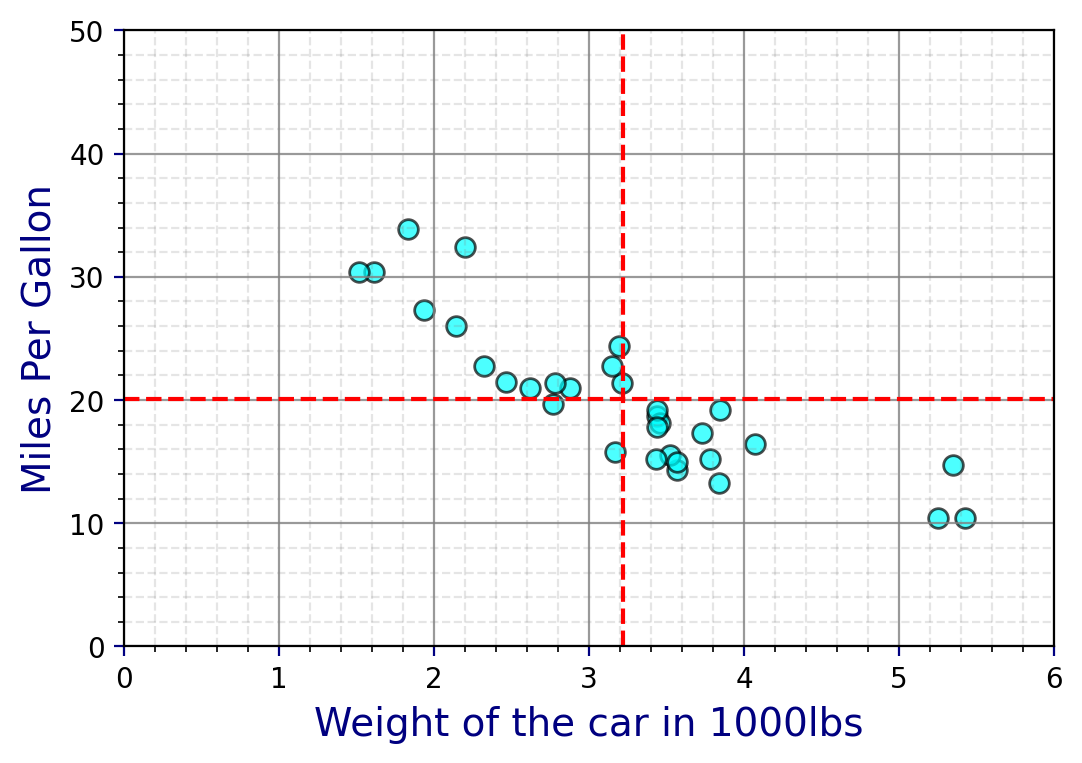

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y,color='cyan',s=50,ec='black',alpha=0.7)
ax.set_xlim(0, 6)
ax.set_ylim(0, 50)
ax.set_xlabel('Weight of the car in 1000lbs',fontsize=14,color='navy')
ax.set_ylabel('Miles Per Gallon',fontsize=14,color='navy')
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
plt.axvline(x=xb, color='red',linestyle='dashed')
plt.axhline(y=yb, color='red',linestyle='dashed')
plt.tick_params(axis='x', color='navy')
plt.tick_params(axis='y', color='navy')
ax.minorticks_on()
plt.show()

In [ ]:
# here we make x a column vector or a matrix
x = x.reshape(-1,1) #technical

In [ ]:
model = LinearRegression()
model.fit(x,y)

LinearRegression()

In [14]:
x

array([2.62 , 2.875, 2.32 , 3.215, 3.44 , 3.46 , 3.57 , 3.19 , 3.15 ,
       3.44 , 3.44 , 4.07 , 3.73 , 3.78 , 5.25 , 5.424, 5.345, 2.2  ,
       1.615, 1.835, 2.465, 3.52 , 3.435, 3.84 , 3.845, 1.935, 2.14 ,
       1.513, 3.17 , 2.77 , 3.57 , 2.78 ])

#### Contour Plots Example

In [25]:
# this is a much simpler format of gradient descent if we only had one input feature and one intercept
def compute_cost(m,b):
    SSE = 0

    # number of datapoints in training data
    N = float(len(data))

    # Compute sum of squared errors
    for i in range(0, len(data)):
        x = data[i, 0]
        y = data[i, 1]
        SSE += (y - (m * x + b)) ** 2

    # Return average of squared error
    return SSE/(2*N)

In [26]:
data = np.column_stack([x,y])

In [27]:
b_range = np.linspace(-120,120,num=4000)
m_range = np.linspace(-120,120,num=4000)
M, B = np.meshgrid(m_range, b_range)
Z = np.log10(compute_cost(M, B))

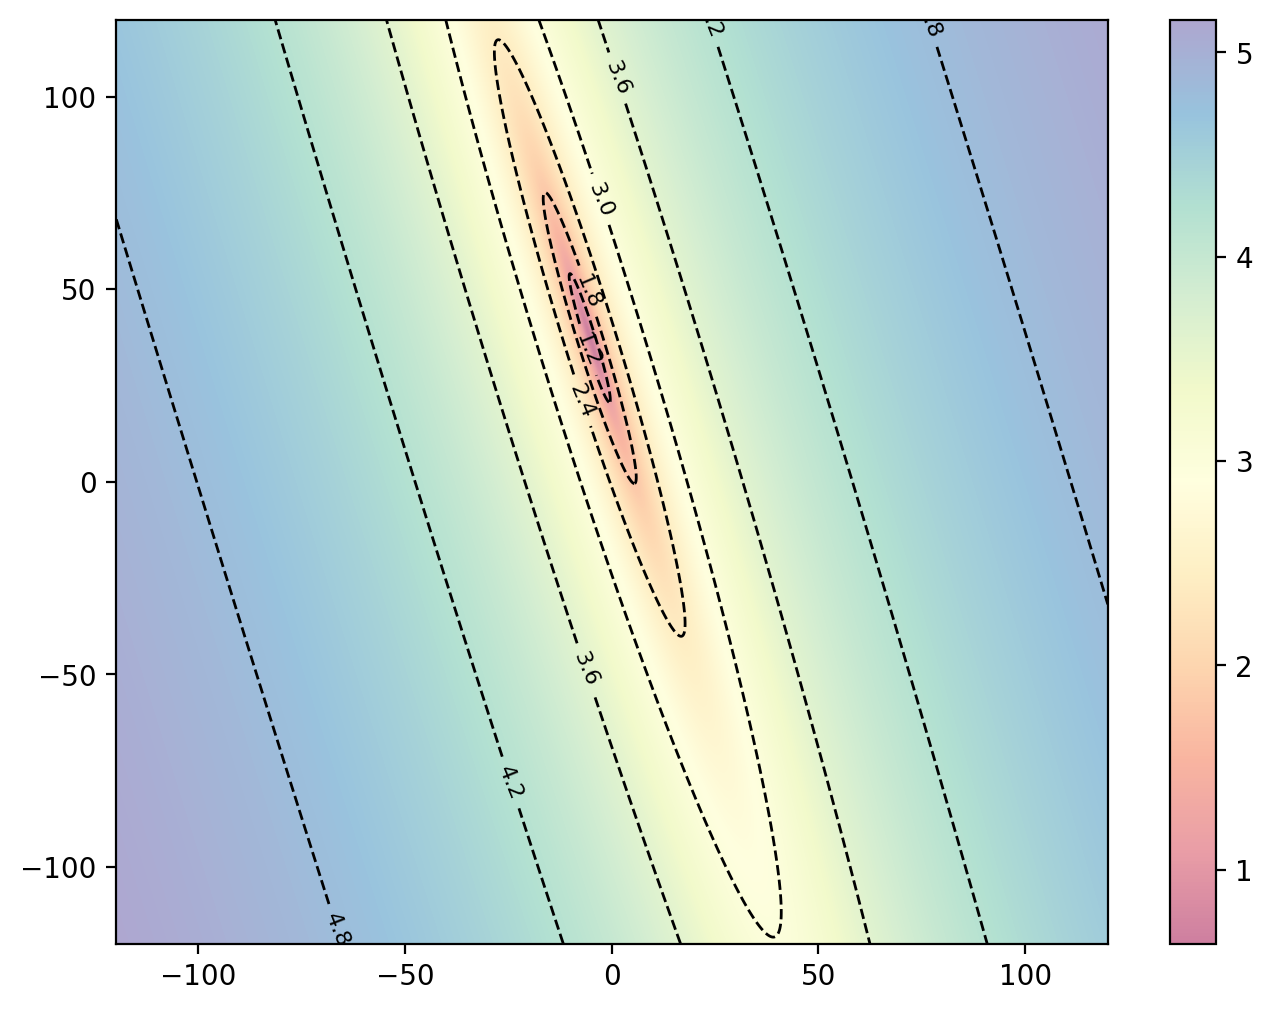

In [28]:
plt.figure(figsize=(8,6))
contours = plt.contour(M,B,Z,colors='black', linestyles='dashed', linewidths=1)
plt.clabel(contours, inline=True, fontsize=8)

plt.imshow(Z, extent=[-120, 120, -120, 120], origin='lower',
           cmap='Spectral', alpha=0.5,aspect='auto', interpolation='bicubic')
plt.colorbar()
plt.show()

In [29]:
m = model.coef_
b = model.intercept_

In [30]:
print('The Slope is :'+str(m),' and the intercept is :' +str(b))

The Slope is :[-5.34447157]  and the intercept is :37.28512616734204


In [ ]:
from scipy.stats import pearsonr

In [ ]:
# we have to "ravel" back the x
x = x.ravel()

In [ ]:
r, pval = pearsonr(x,y)
print('The correlation coefficient is :'+str(r)+'  and the pvalue for significance is :'+str(pval))

The correlation coefficient is :-0.8676593765172278  and the pvalue for significance is :1.293958701350513e-10


In [ ]:
m = r*np.std(y)/np.std(x)

In [ ]:
print('The slope of the trend is :' +str(m))

The slope of the trend is :-5.344471572722676


The equation of the line passing through the center of mass and that captires the trend is:
$$y-\bar{y} = m\cdot(x-\bar{x})$$

In short, $$y=m\cdot x + b$$ where $b = \bar{y} -m\cdot\bar{x}$

In [ ]:
b = yb-m*xb
print('In our case the intercept is: ' +str(b)) # what is the meaning of the intercept?

In our case the intercept is: 37.285126167342035


#### <font color='blue'> OLS Equivalence </font>

The main idea is that in 1-D the OLS estimation is equivalence with the calculation of the slope via the Pearson correlation coefficient.

In [ ]:
def loss(b, m, data): # this is also called "loss" function
    total_cost = 0

    # number of datapoints in training data
    N = float(len(data))

    # Compute sum of squared errors
    for i in range(0, len(data)):
        x = data[i, 0]
        y = data[i, 1]
        total_cost += (y - (m * x + b)) ** 2

    # Return average of squared error
    return total_cost/N

In [ ]:
# this is the actual gradient descent
def step_gradient(b_current, m_current, data, alpha):
    """takes one step down towards the minima

    Args:
        b_current (float): current value of b
        m_current (float): current value of m
        data (np.array): array containing the training data (x,y)
        alpha (float): learning rate / step size

    Returns:
        tuple: (b,m) new values of b,m
    """

    m_gradient = 0
    b_gradient = 0
    N = float(len(data))

    # Calculate Gradient - assuming you know partial derivatives
    for i in range(0, len(data)):
        x = data[i, 0]
        y = data[i, 1]
        m_gradient += - (2/N) * x * (y - (m_current * x + b_current)) # is the partial derivative with respect to m
        b_gradient += - (2/N) * (y - (m_current * x + b_current)) # is the partial derivative with respect to b

    # Update current m and b, alpha stands for learning rate
    # we proceed in the direction of the negative gradient
    m_updated = m_current - alpha * m_gradient
    b_updated = b_current - alpha * b_gradient

    #Return updated parameters
    return b_updated, m_updated

def gradient_descent(data, starting_b, starting_m, learning_rate, num_iterations):
    """runs gradient descent

    Args:
        data (np.array): training data, containing x,y
        starting_b (float): initial value of b (random)
        starting_m (float): initial value of m (random)
        learning_rate (float): hyperparameter to adjust the step size during descent
        num_iterations (int): hyperparameter, decides the number of iterations for which gradient descent would run

    Returns:
        list : the first and second item are b, m respectively at which the best fit curve is obtained, the third and fourth items are two lists, which store the value of b,m as gradient descent proceeded.
    """

    # initial values
    b = starting_b
    m = starting_m

    # to store the cost after each iteration
    cost_graph = []

    # to store the value of b -> bias unit, m-> slope of line after each iteration (pred = m*x + b)
    b_progress = []
    m_progress = []

    # For every iteration, optimize b, m and compute its cost
    for i in range(num_iterations):
        cost_graph.append(loss(b, m, data))
        b, m = step_gradient(b, m, data, learning_rate)
        b_progress.append(b)
        m_progress.append(m)

    return [b, m, cost_graph,b_progress,m_progress]

In [ ]:
#hyperparamters
learning_rate = 0.001
initial_b = 12
initial_m = 3
num_iterations = 50000
data = np.column_stack([x,y])

In [ ]:
b, m, cost_graph,b_progress,m_progress = gradient_descent(data, initial_b, initial_m, learning_rate, num_iterations)

#Print optimized parameters
print ('Optimized b:', b)
print ('Optimized m:', m)

#Print error with optimized parameters
print ('Minimized cost:', loss(b, m, data))

Optimized b: 37.27234604666433
Optimized m: -5.340801130745784
Minimized cost: 8.697573986717137


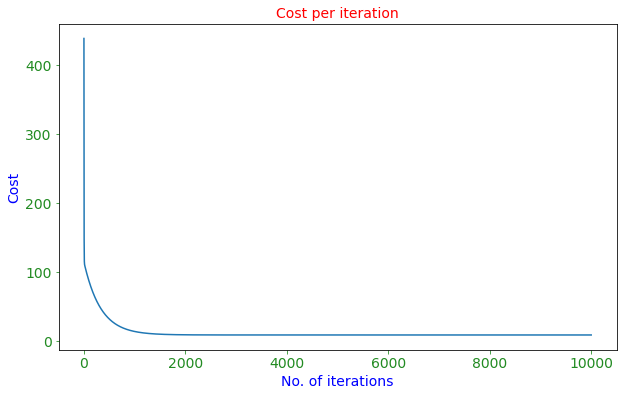

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
plt.plot(cost_graph)
ax.set_xlabel('No. of iterations',fontsize=14,color='blue')
ax.set_ylabel('Cost',fontsize=14,color='blue')
plt.title('Cost per iteration',color='red',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax.tick_params(axis='x', colors='forestgreen')
ax.tick_params(axis='y', colors='forestgreen')
plt.show()

In [ ]:
model.coef_ , model.intercept_ # this is what the has learned

(array([-5.34447157]), 37.28512616734204)

In [ ]:
x_range = np.linspace(np.min(x)-1,np.max(x)+1,2)
yhat = model.predict(x_range.reshape(-1,1))

In [ ]:
#Plot dataset
plt.scatter(x, y,ec='k',color='cyan',alpha=0.6)
#Predict y values
pred = model.coef_ * x_range + model.intercept_
#Plot predictions as line of best fit
plt.plot(x_range, pred, c='g')
plt.xlim(0, 6)
plt.ylim(0, 50)
plt.xlabel('Independent Variable $X$',fontsize=14,color='navy')
plt.ylabel('Dependent Variable $Y$',fontsize=14,color='navy')
plt.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
plt.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
plt.axvline(x=xb, color='red',linestyle='dashed')
plt.axhline(y=yb, color='purple',linestyle='dashed')
plt.tick_params(axis='x', color='navy')
plt.tick_params(axis='y', color='navy')
plt.minorticks_on()
plt.title('Line of best fit',fontsize=14)
plt.legend(['Data','Trend','Mean of $X$','Mean of $Y$'])
plt.savefig('lineacorrelation.png',dpi=300)
plt.show()

In [ ]:
model.score(x.reshape(-1,1),y)

0.7528327936582646

In [ ]:
r**2

0.7528327936582647

####   <font color='blue'>Test the Residuals for Goodness of fit</font>

We investigate the distribution of the residuals, plot a histogram and apply a normality test

In [ ]:
residuals = y - model.predict(x.reshape(-1,1))

In [ ]:
import seaborn as sns

# import uniform distribution
from scipy import stats
from scipy.stats import norm

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


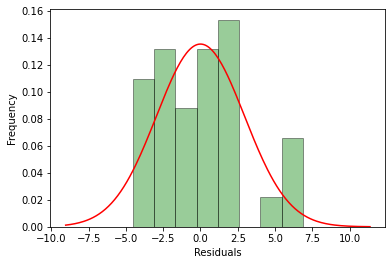

In [ ]:
ax1 = sns.distplot(residuals,

                  bins=8,
                  kde=False,
                  color='deepskyblue',
                  hist_kws={"color":'green','ec':'black'},
                  fit=stats.norm,
                  fit_kws={"color":'red'})
ax1.set(xlabel='Residuals', ylabel='Frequency')
plt.show()

## <font color='blue'> Polynomial Regression</font>

<font color='slateblue'> Main idea: Linear combination of different powers of the feature values. </font>

$$\large
P(x):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

IMPORTANT: P(x) is nonlinear in x. However if x is fixed (x is your data) and $\beta$ is the input we have
$$\large
L(\beta):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

is linear in $\beta$


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

## Example in 1-D

$$\large p(x) = \frac{1}{4}x^3-\frac{3}{2}x^2+x$$

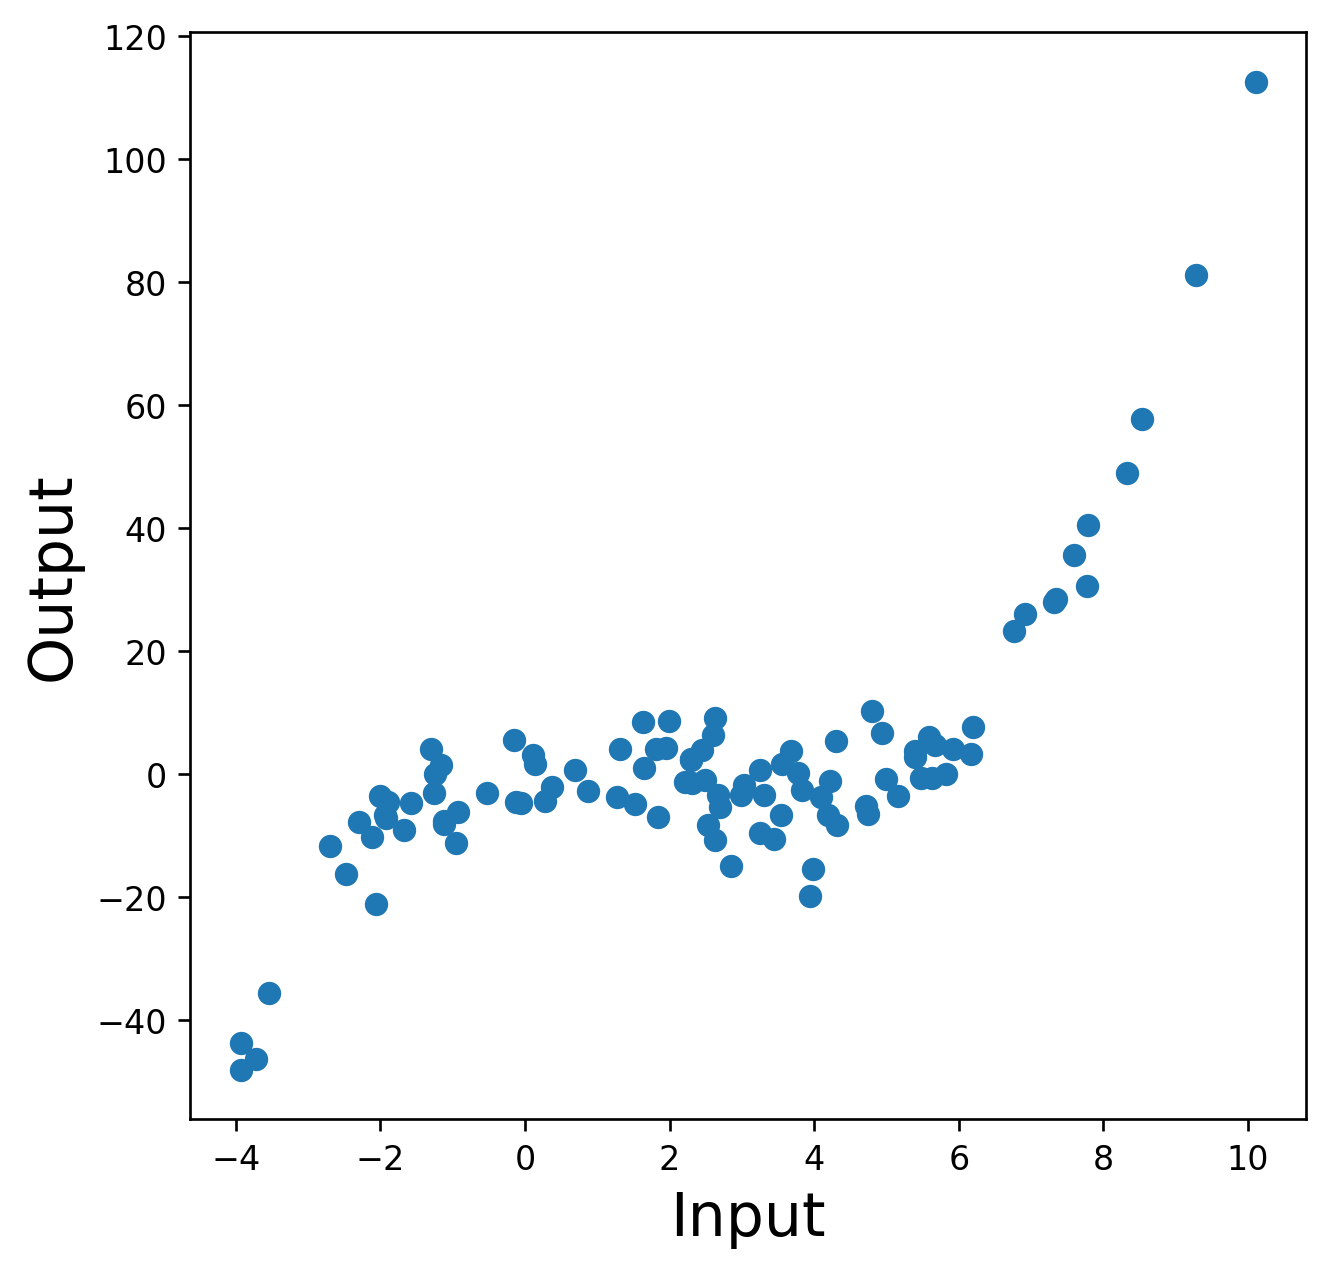

In [ ]:
np.random.seed(1693)
x = 2 - 3 * np.random.normal(0, 1, 100) # this means non-equally spaced values
y = x - 1.5 * (x ** 2) + 0.25 * (x ** 3) + 5*np.random.normal(loc=0,scale=1,size=100) # we generate a cubic relationship between x and y
plt.figure(figsize=(6,6))
plt.scatter(x,y)
plt.xlabel('Input',fontsize=18)
plt.ylabel('Output',fontsize=18)
plt.show()

### <font color='fuchsia'> Is a straight line a good idea for capturing the aspect?

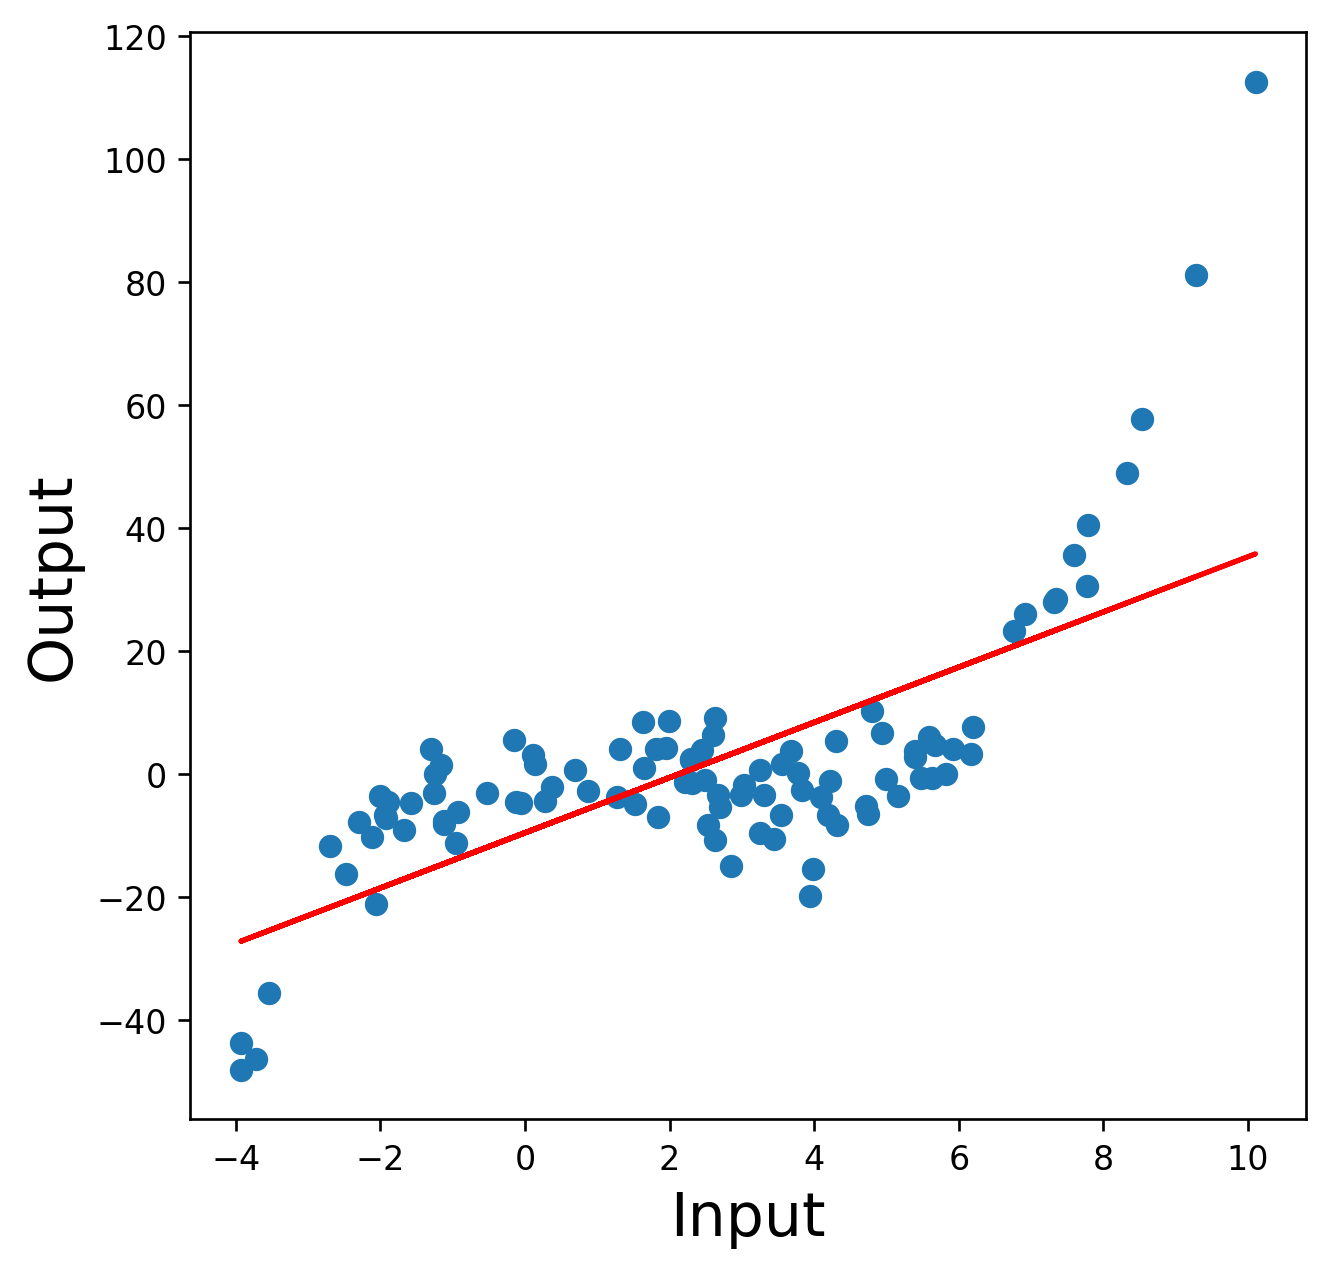

In [ ]:
from sklearn import linear_model
lm = linear_model.LinearRegression()

model = lm.fit(x.reshape((-1,1)),y)
y_pred = lm.predict(x.reshape((-1,1)))
plt.figure(figsize=(6,6))
plt.scatter(x, y)
plt.plot(x, y_pred, '-',color='r')
plt.xlabel('Input',fontsize=18)
plt.ylabel('Output',fontsize=18)
plt.show()

In [ ]:
import operator
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

5.369973037195503
0.9332479212313307


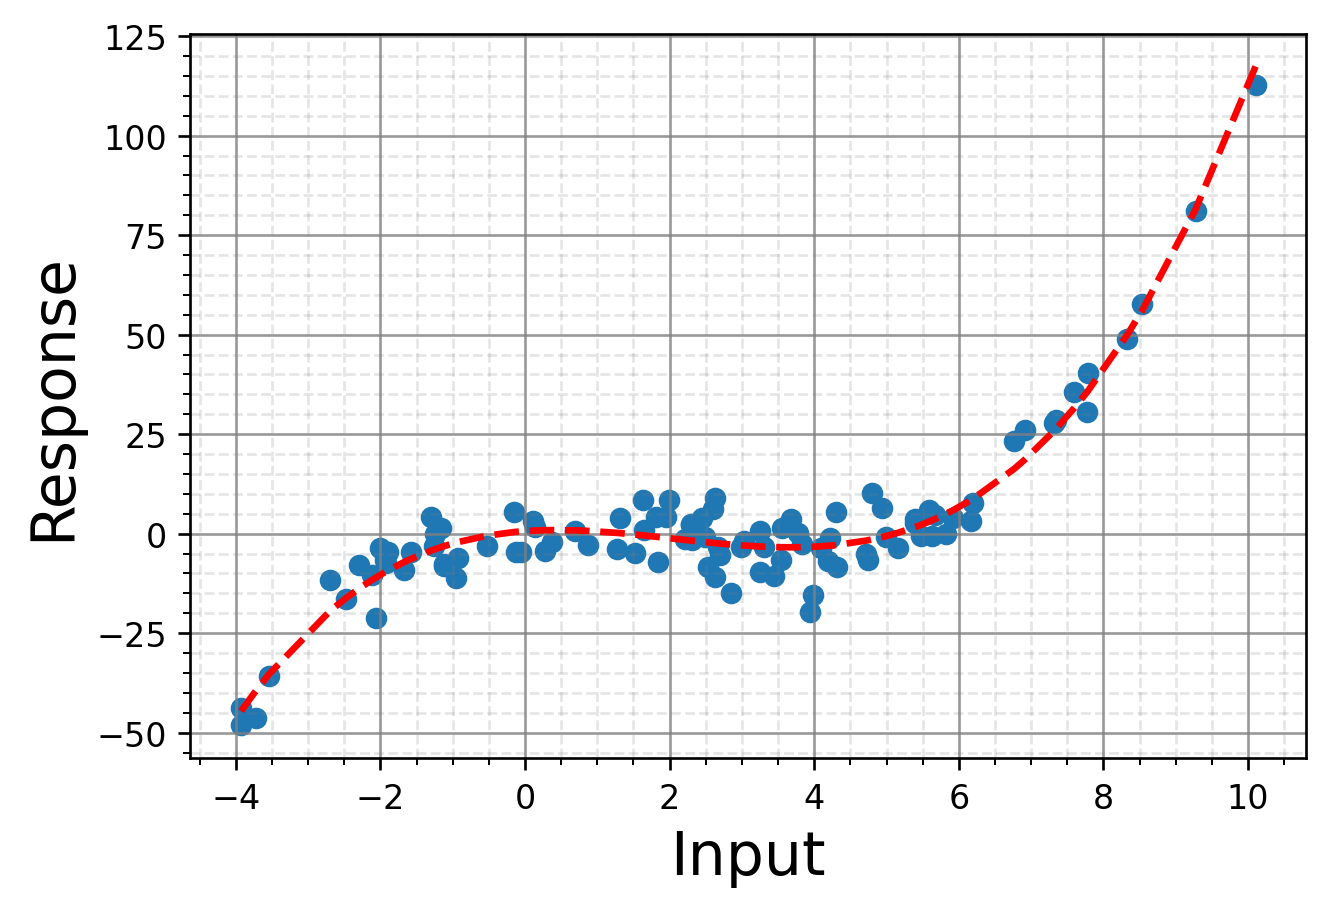

<Figure size 720x720 with 0 Axes>

In [ ]:
np.random.seed(1693)
x = 2 - 3 * np.random.normal(0, 1, 100)

def f(x):
    sz = len(x)
    return x - 1.5 * (x ** 2) + 0.25 * (x ** 3) + 5 * np.random.normal(loc=0, scale=1, size=sz)

y = f(x)

polynomial_features= PolynomialFeatures(degree=3)
x_poly = polynomial_features.fit_transform(x.reshape((-1,1)))

# the model created is linear in weights
model = LinearRegression()
model.fit(x_poly, y)
y_poly_pred = model.predict(x_poly)

rmse = np.sqrt(mean_squared_error(y,y_poly_pred))
r2 = r2_score(y,y_poly_pred)
print(rmse)
print(r2)

fig, ax = plt.subplots()
plt.figure(figsize=(6,6))
ax.scatter(x, y, s=30)
# sort the values of x before line plot
sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
x, y_poly_pred = zip(*sorted_zip)
ax.plot(x, y_poly_pred, color='r',linestyle='--',lw=2)
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Response',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

In [ ]:
model.coef_

array([ 0.        ,  1.26204772, -1.59419899,  0.25857094])

In [ ]:
pd.DataFrame(x_poly)

,0,1,2,3,4
0,1.0,4.741352,22.480420,106.587590,505.369302
1,1.0,3.554897,12.637292,44.924268,159.701140
2,1.0,0.105749,0.011183,0.001183,0.000125
3,1.0,1.626725,2.646233,4.304692,7.002549
4,1.0,3.252754,10.580411,34.415480,111.945106
...,...,...,...,...,...
95,1.0,-1.257303,1.580812,-1.987560,2.498966
96,1.0,3.685663,13.584110,50.066446,184.528032
97,1.0,3.253514,10.585350,34.439581,112.049645
98,1.0,-3.928013,15.429287,-60.606442,238.062900


# <font color='blue'> Polynomial Regression</font>

## 1. Polynomials in one variable

<font color='slateblue'> Main idea: Linear combination of different powers of the feature values.

$$\large
P(x):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

What we hope to achieve:

$$\large \mathbb{E}(Y|X=x)\approx \beta_p x^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0$$

IMPORTANT: P(x) is nonlinear in x. However if x is fixed (x is your data) and $\beta$ is the input we have
$$\large
L(\beta):= \beta_px^p+\beta_{p-1}x^{p-1}+...+\beta_1x+\beta_0
$$

is linear in $\beta=(\beta_0,\beta_1,\beta_2,...\beta_p).$

$$\large L(\beta+\gamma)= L(\beta)+L(\gamma)$$

and

$$\large L(c\cdot \beta) = c\cdot L(\beta)$$

for any two vectors $\beta$ and $\gamma$, and any scalar (real number) $c.$


### The Coefficient of Determination

$$\large R^2:=1-\frac{\sum (residual_i)^2}{\sum(y_i-\bar{y})^2}$$

We can solve for the sum of squared residuals:

$$\large \frac{\sum (residual_i)^2}{\sum(y_i-\bar{y})^2}= 1- R^2$$

so we obtain:

$$\large \sum (residual_i)^2= \sum(y_i-\bar{y})^2\cdot (1-R^2)$$

We got that

$$\Large \text{MSE} = \frac{1}{n}\cdot \sum(y_i-\bar{y})^2\cdot (1-R^2)$$


### Example

What is the format of a quadratic polynomial of two variables, say $u$ and $v$:

$$\large \text{poly}(u,v):=\beta_0+\beta_1\cdot u+\beta_2\cdot u^2 + \beta_3 v + \beta_4 v^2 +\beta_5 u\cdot v$$

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import numpy as np
import operator
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

In [3]:
# here we simulate polynomial data
np.random.seed(123)
x = 2 - 3 * np.random.normal(loc=0,scale=1,size=150)
y = x - 1.4 * (x ** 2) + 0.25 * (x ** 3) + 2.5*np.random.normal(loc=-3, scale=3,size=150)
# we simulated the polynomial x-1.5*x^2+0.25*x^3 and we added some Gaussian noise

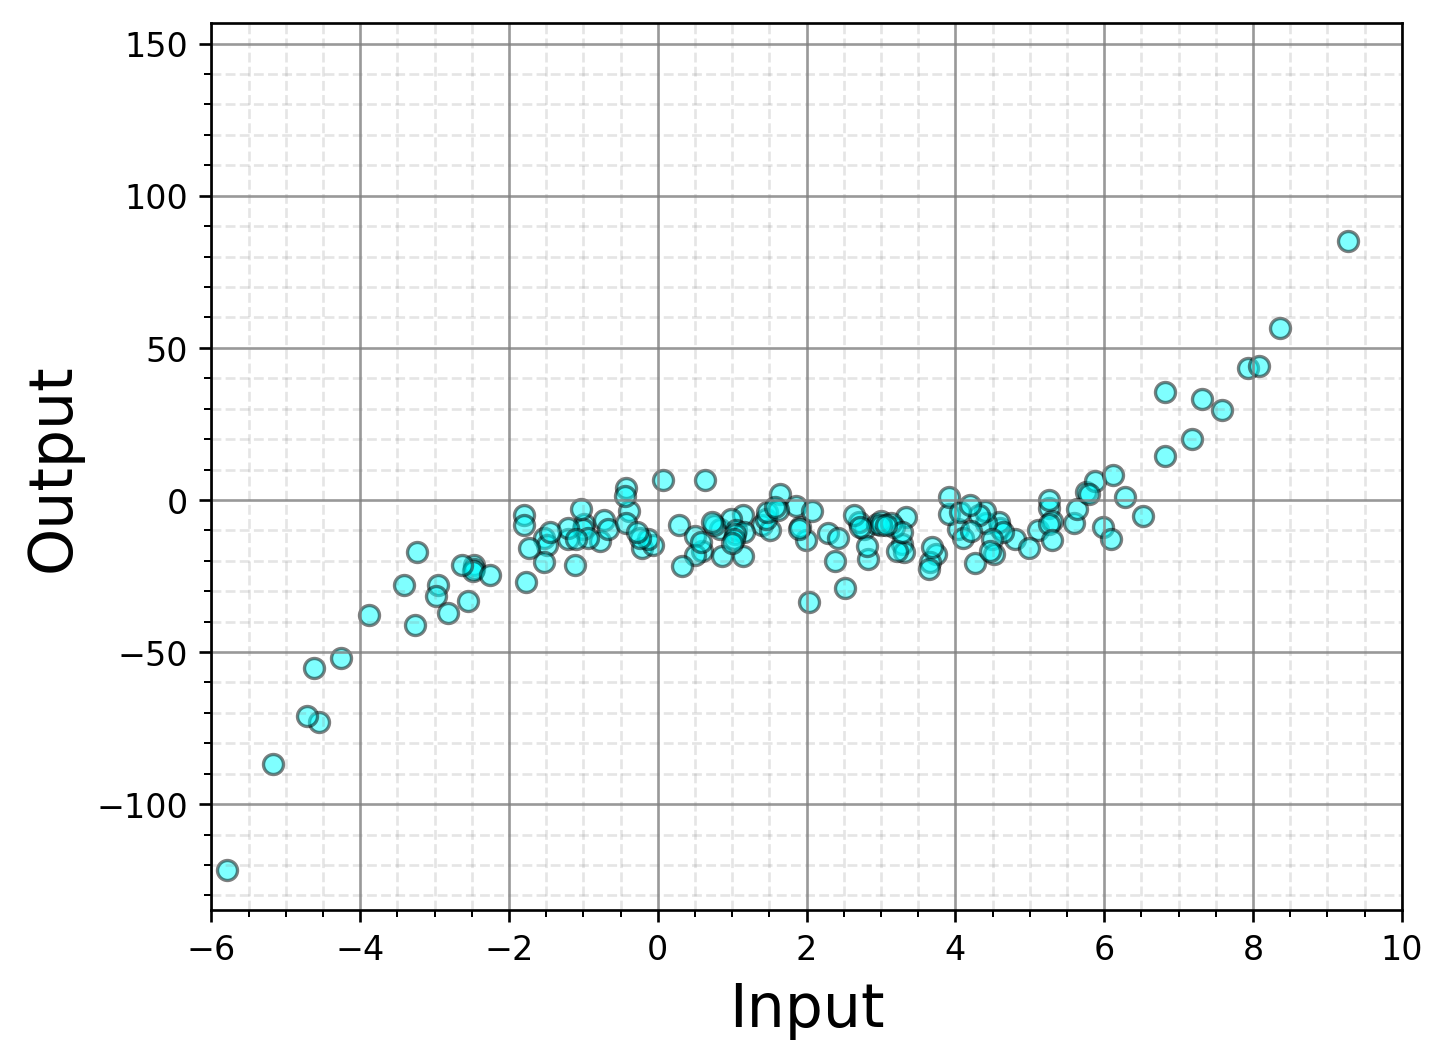

In [4]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6) # here we setup a desired figure size.
ax.scatter(x,y,ec='k',color='cyan',alpha=0.5) # we generate a scatter plot of x and y
ax.set_xlim([-6,10]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

### <font color='red'> Critical Thinking: Is a straight line a good idea for capturing the relationship between x and y?

In [ ]:
x.shape

(100,)

In [5]:
model = LinearRegression()

In [6]:
model.fit(x.reshape(-1,1),y)
y_pred = model.predict(x.reshape((-1,1)))

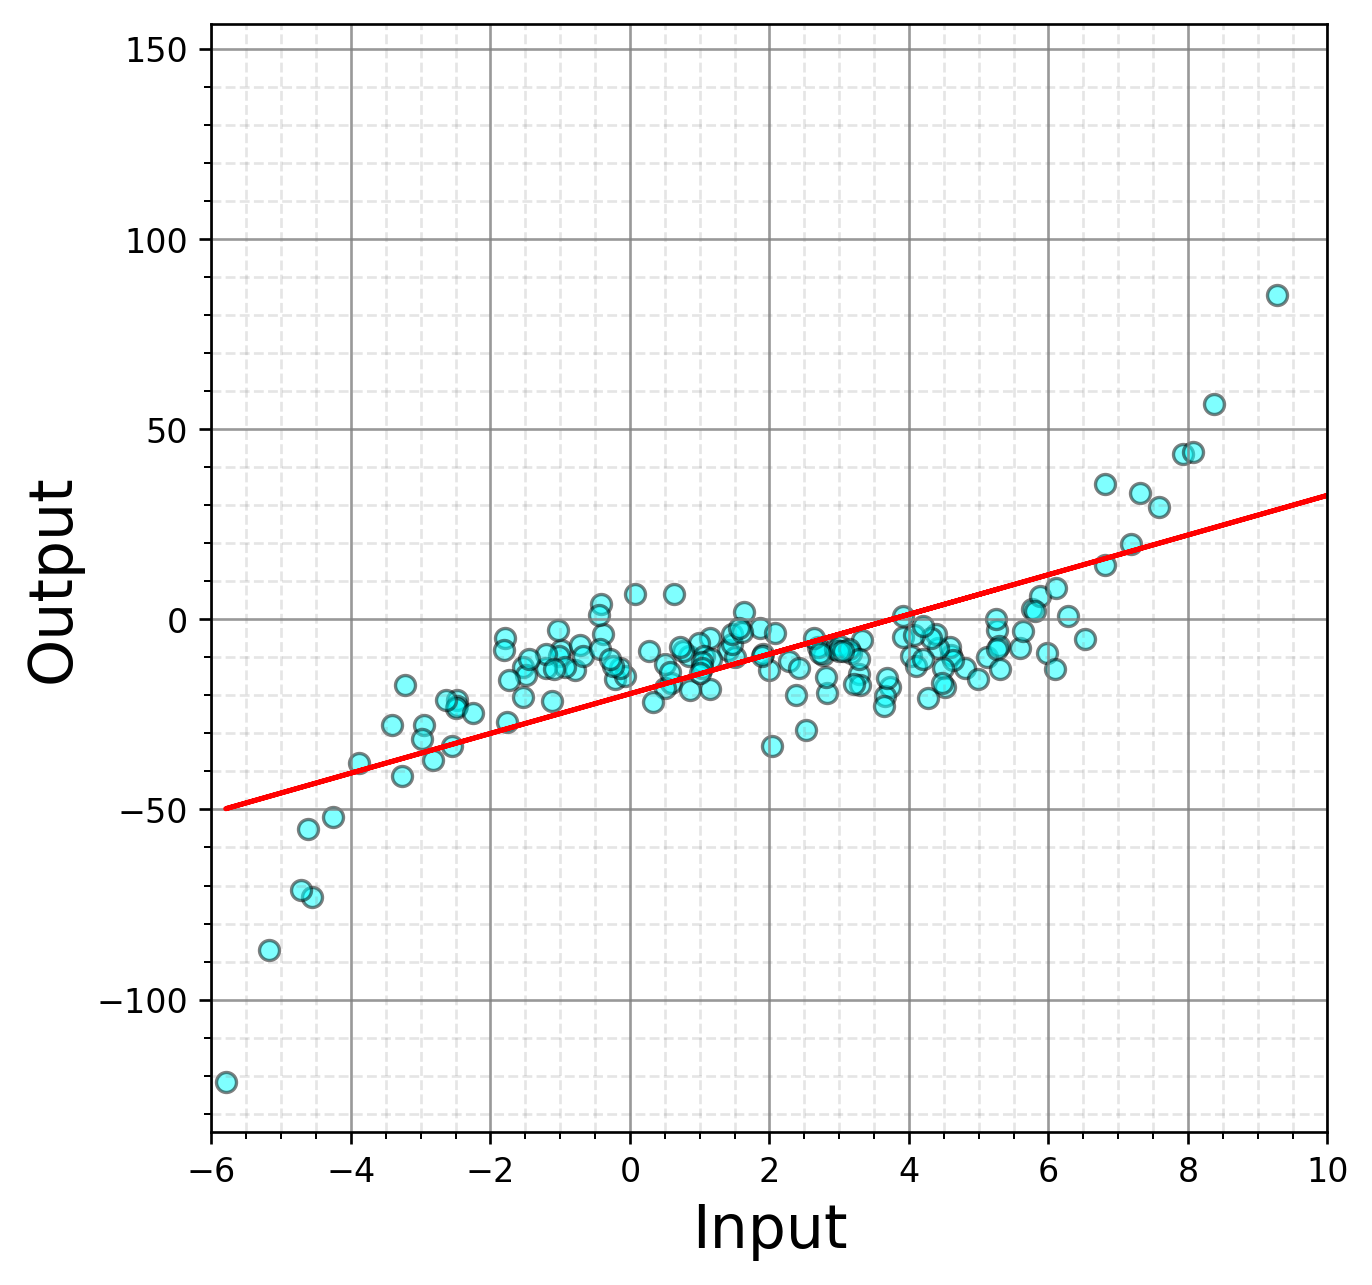

In [7]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (8,8) # here we setup a desired figure size.
ax.scatter(x,y,ec='k',color='cyan',alpha=0.5) # we generate a scatter plot of x and y
ax.plot(x, y_pred, '-',color='r') # here we plot the line
ax.set_xlim([-6,10]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

In [10]:
ind = (np.abs(y-model.predict(x.reshape(-1,1)))<5)

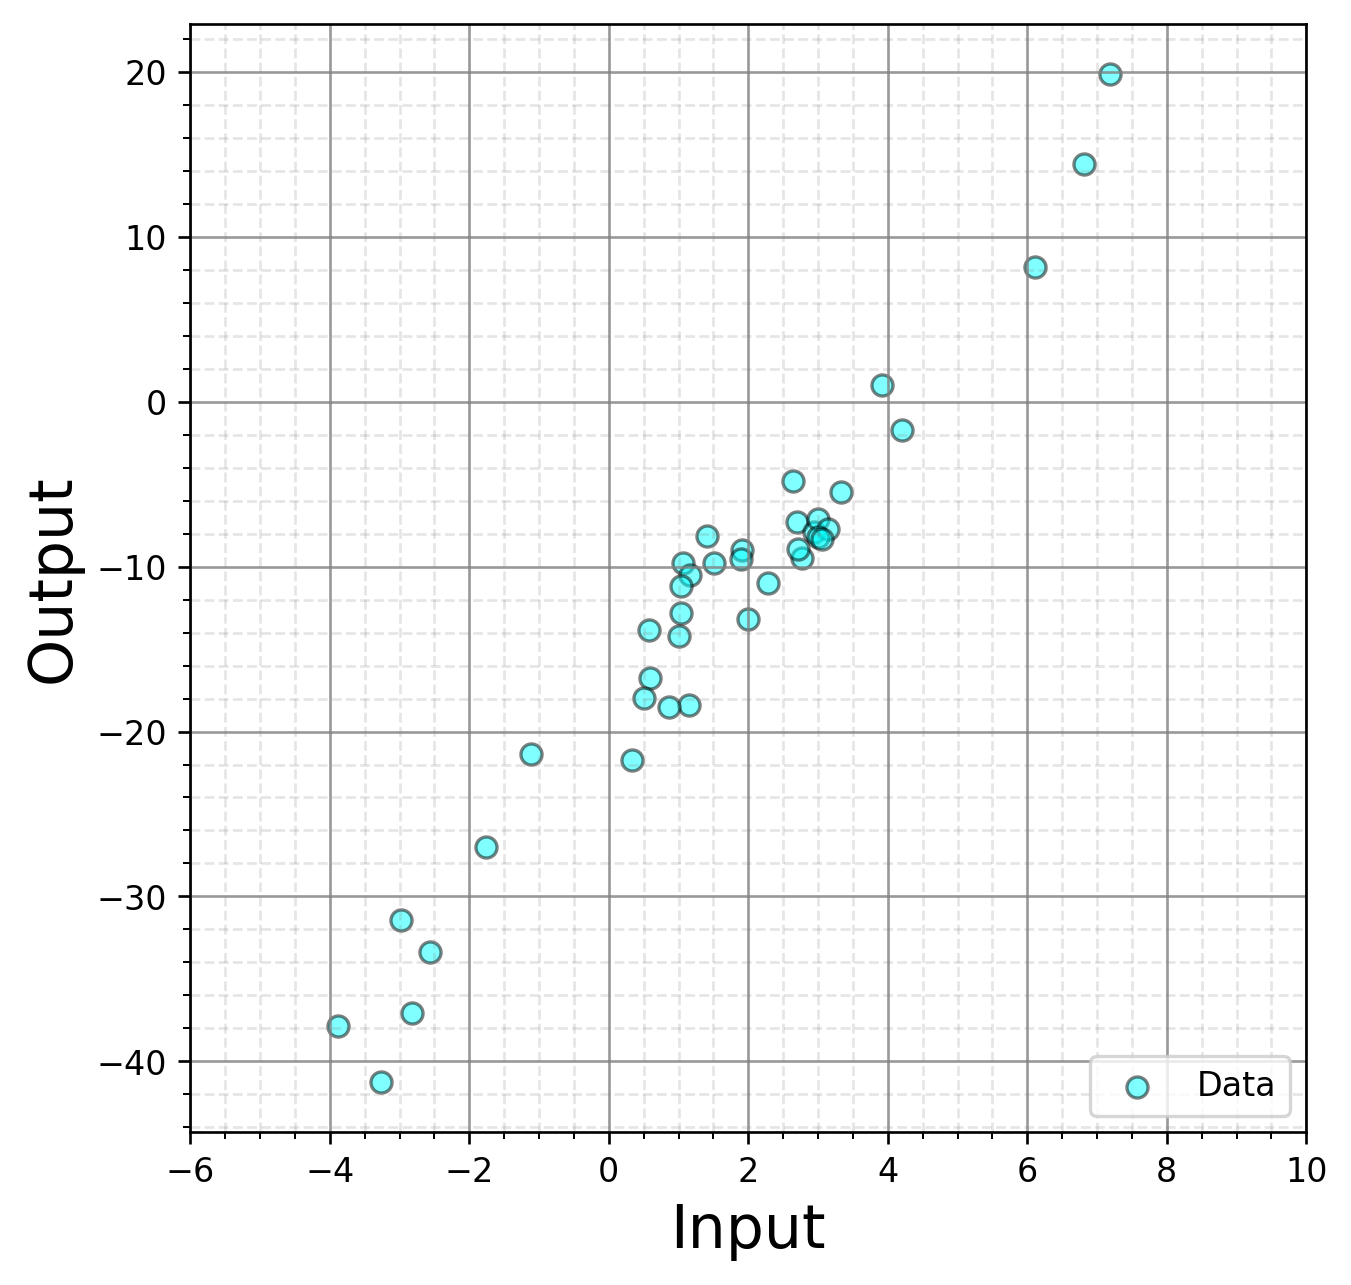

In [12]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6) # here we setup a desired figure size.
ax.scatter(x[ind],y[ind],ec='k',s=40,color='cyan',alpha=0.5,label='Data') # we generate a scatter plot of x and y
ax.set_xlim([-6,10]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.legend(loc='lower right')
plt.savefig('train.png',dpi=300)
plt.show()

In [ ]:
# we want the R2 score (coefficient of determination)
model.score(x.reshape(-1,1),y)

0.4681903341708725

In [23]:
lm = LinearRegression()
lm.fit(x[ind].reshape(-1,1),y[ind])

LinearRegression()

In [24]:
yhat = lm.predict(np.array([-5,8]).reshape(-1,1))

ValueError: keyword grid_b is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid_caps

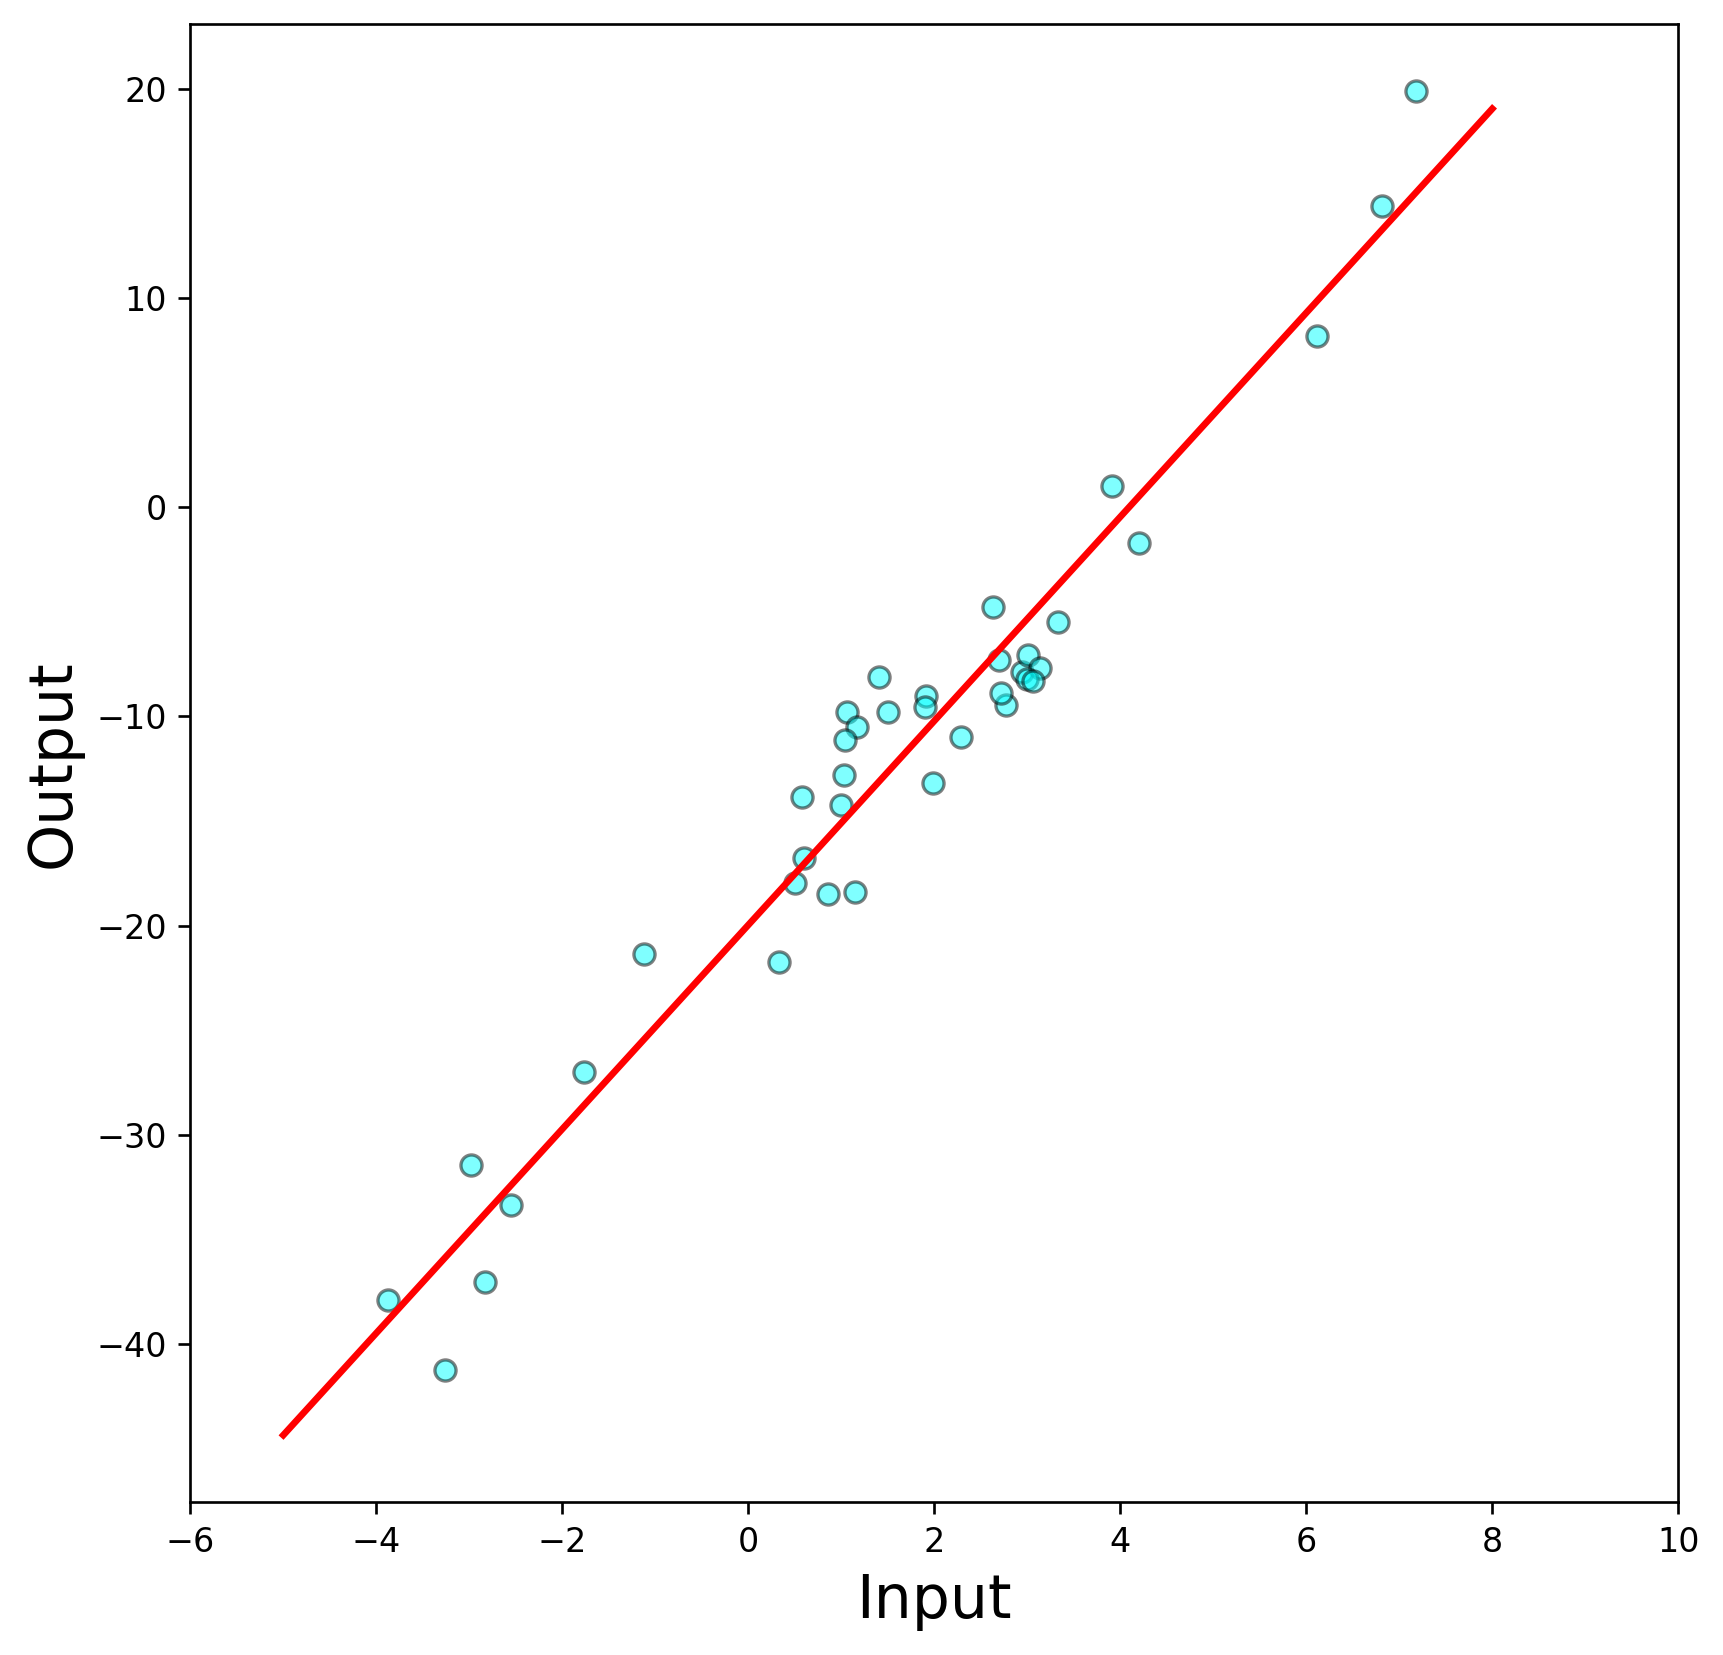

In [25]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (8,8) # here we setup a desired figure size.
ax.scatter(x[ind],y[ind],ec='k',s=40,color='cyan',alpha=0.5,label='Data') # we generate a scatter plot of x and y
ax.plot([-5,8],yhat,color='red',lw=2,label='Linear Model')
ax.set_xlim([-6,10]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.legend(loc='lower right')
plt.savefig('train_linear.png',dpi = 300)
plt.show()

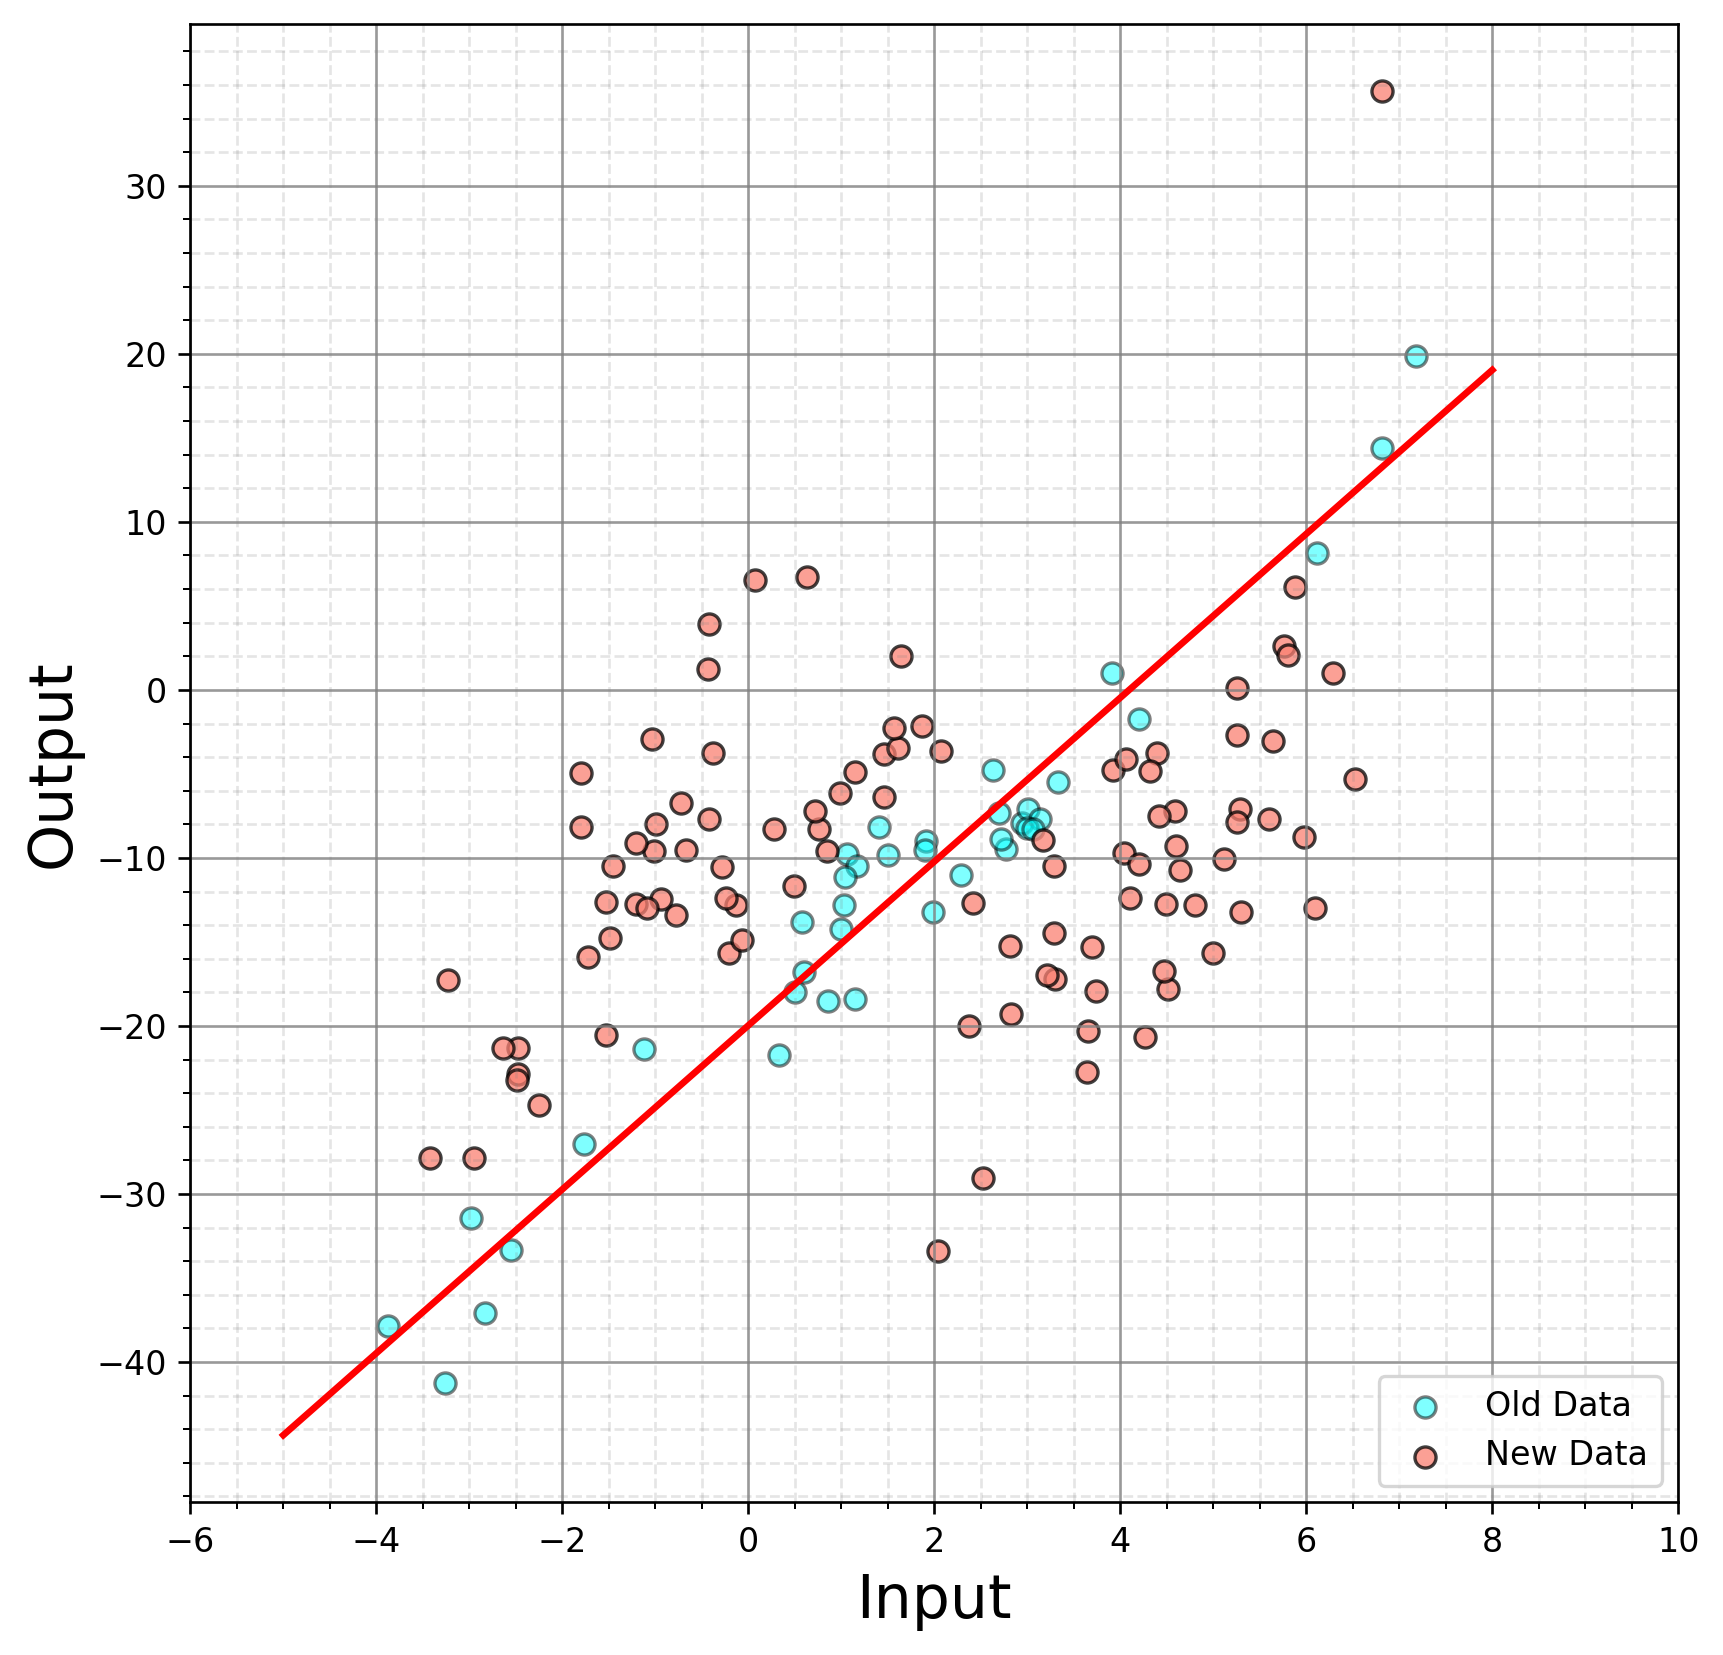

In [26]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (8,8) # here we setup a desired figure size.
ax.scatter(x[ind],y[ind],ec='k',s=40,color='cyan',alpha=0.5,label='Old Data') # we generate a scatter plot of x and y
ax.scatter(x[(~ind)&(x>-4)&(x<7)],y[~ind&(x>-4)&(x<7)],ec='k',s=40,color='salmon',alpha=0.75,label='New Data') # we generate a scatter plot of x and y
ax.plot([-5,8],yhat,color='red',lw=2)
ax.set_xlim([-6,10]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.legend(loc='lower right')
plt.savefig('traintest.png',dpi = 300)
plt.show()

In [ ]:
r2_score(y,model.predict(x.reshape(-1,1)))

0.4681903341708725

### Here we make polynomial features

In [16]:
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(x.reshape((-1,1))) # in x_poly we get the polynomial features

In [18]:
x_poly

array([[ 1.00000000e+00,  5.25689181e+00,  2.76349115e+01,
         1.45273740e+02,  7.63688334e+02],
       [ 1.00000000e+00, -9.92036340e-01,  9.84136099e-01,
        -9.76298774e-01,  9.68523862e-01],
       [ 1.00000000e+00,  1.15106451e+00,  1.32494950e+00,
         1.52510234e+00,  1.75549117e+00],
       [ 1.00000000e+00,  6.51888414e+00,  4.24958505e+01,
         2.77025526e+02,  1.80589731e+03],
       [ 1.00000000e+00,  3.73580076e+00,  1.39562073e+01,
         5.21376097e+01,  1.94775722e+02],
       [ 1.00000000e+00, -2.95430961e+00,  8.72794528e+00,
        -2.57850526e+01,  7.61770288e+01],
       [ 1.00000000e+00,  9.28003773e+00,  8.61191003e+01,
         7.99188500e+02,  7.41649943e+03],
       [ 1.00000000e+00,  3.28673789e+00,  1.08026459e+01,
         3.55054657e+01,  1.16697159e+02],
       [ 1.00000000e+00, -1.79780878e+00,  3.23211640e+00,
        -5.81072722e+00,  1.04465764e+01],
       [ 1.00000000e+00,  4.60022121e+00,  2.11620352e+01,
         9.73500429e+01

In [19]:
# the model created is linear in weights
model = LinearRegression(fit_intercept=False)
model.fit(x_poly, y) # so we fit linear regression of polynomial features
y_poly_pred = model.predict(x_poly)

In [20]:
model.score(x_poly,y)

0.9212634691651588

In [15]:
model.score(x_poly,y)

0.9210046287352598

In [ ]:
model.intercept_

0.0

In [ ]:
r2 = r2_score(y,y_poly_pred)
print(r2)

0.9065900793800235


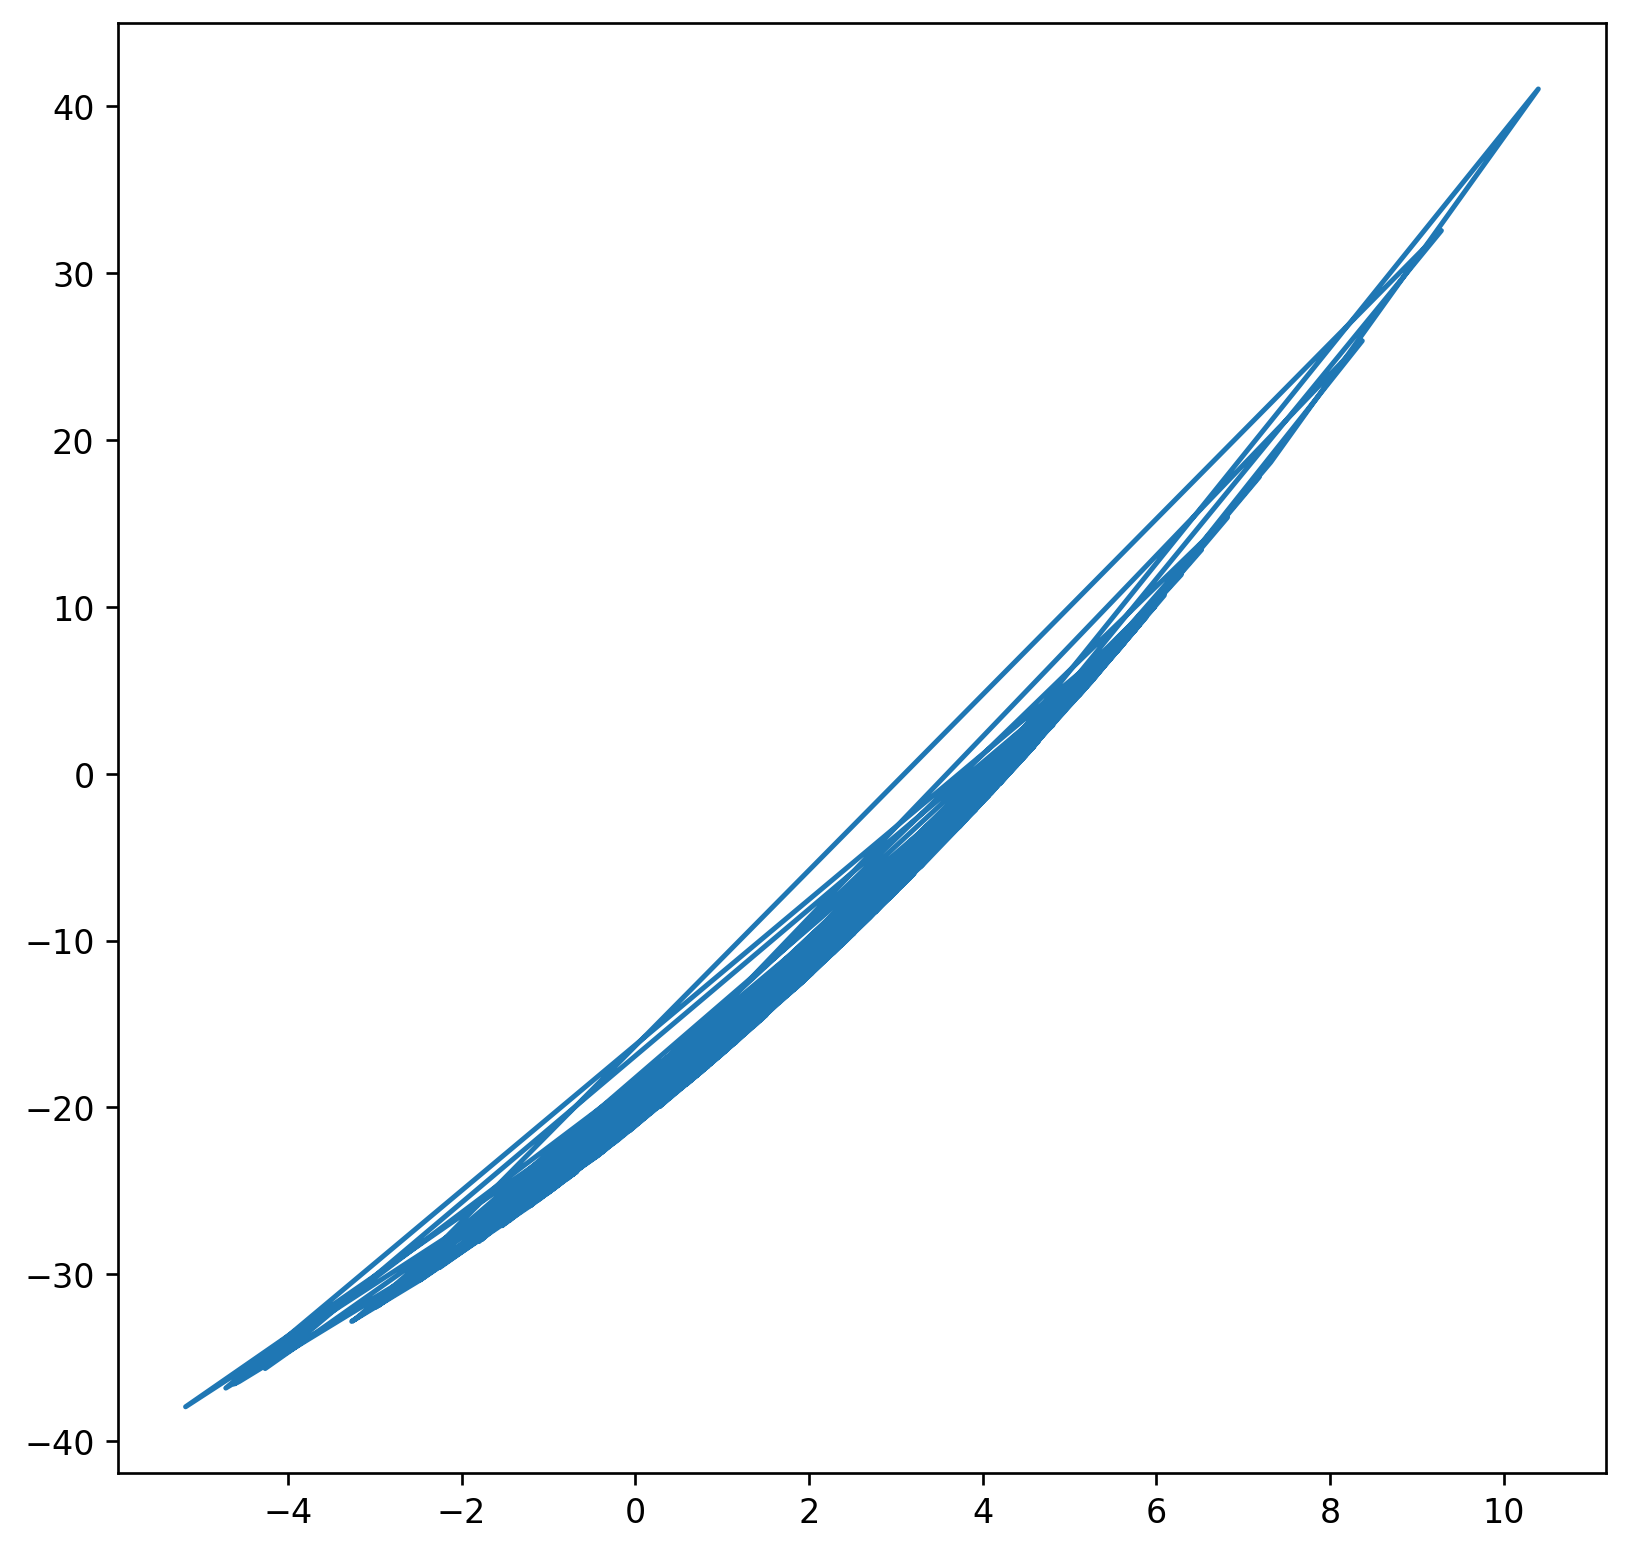

In [ ]:
# this is the wrong way to visualize x vs predicted values.
plt.plot(x,y_poly_pred)

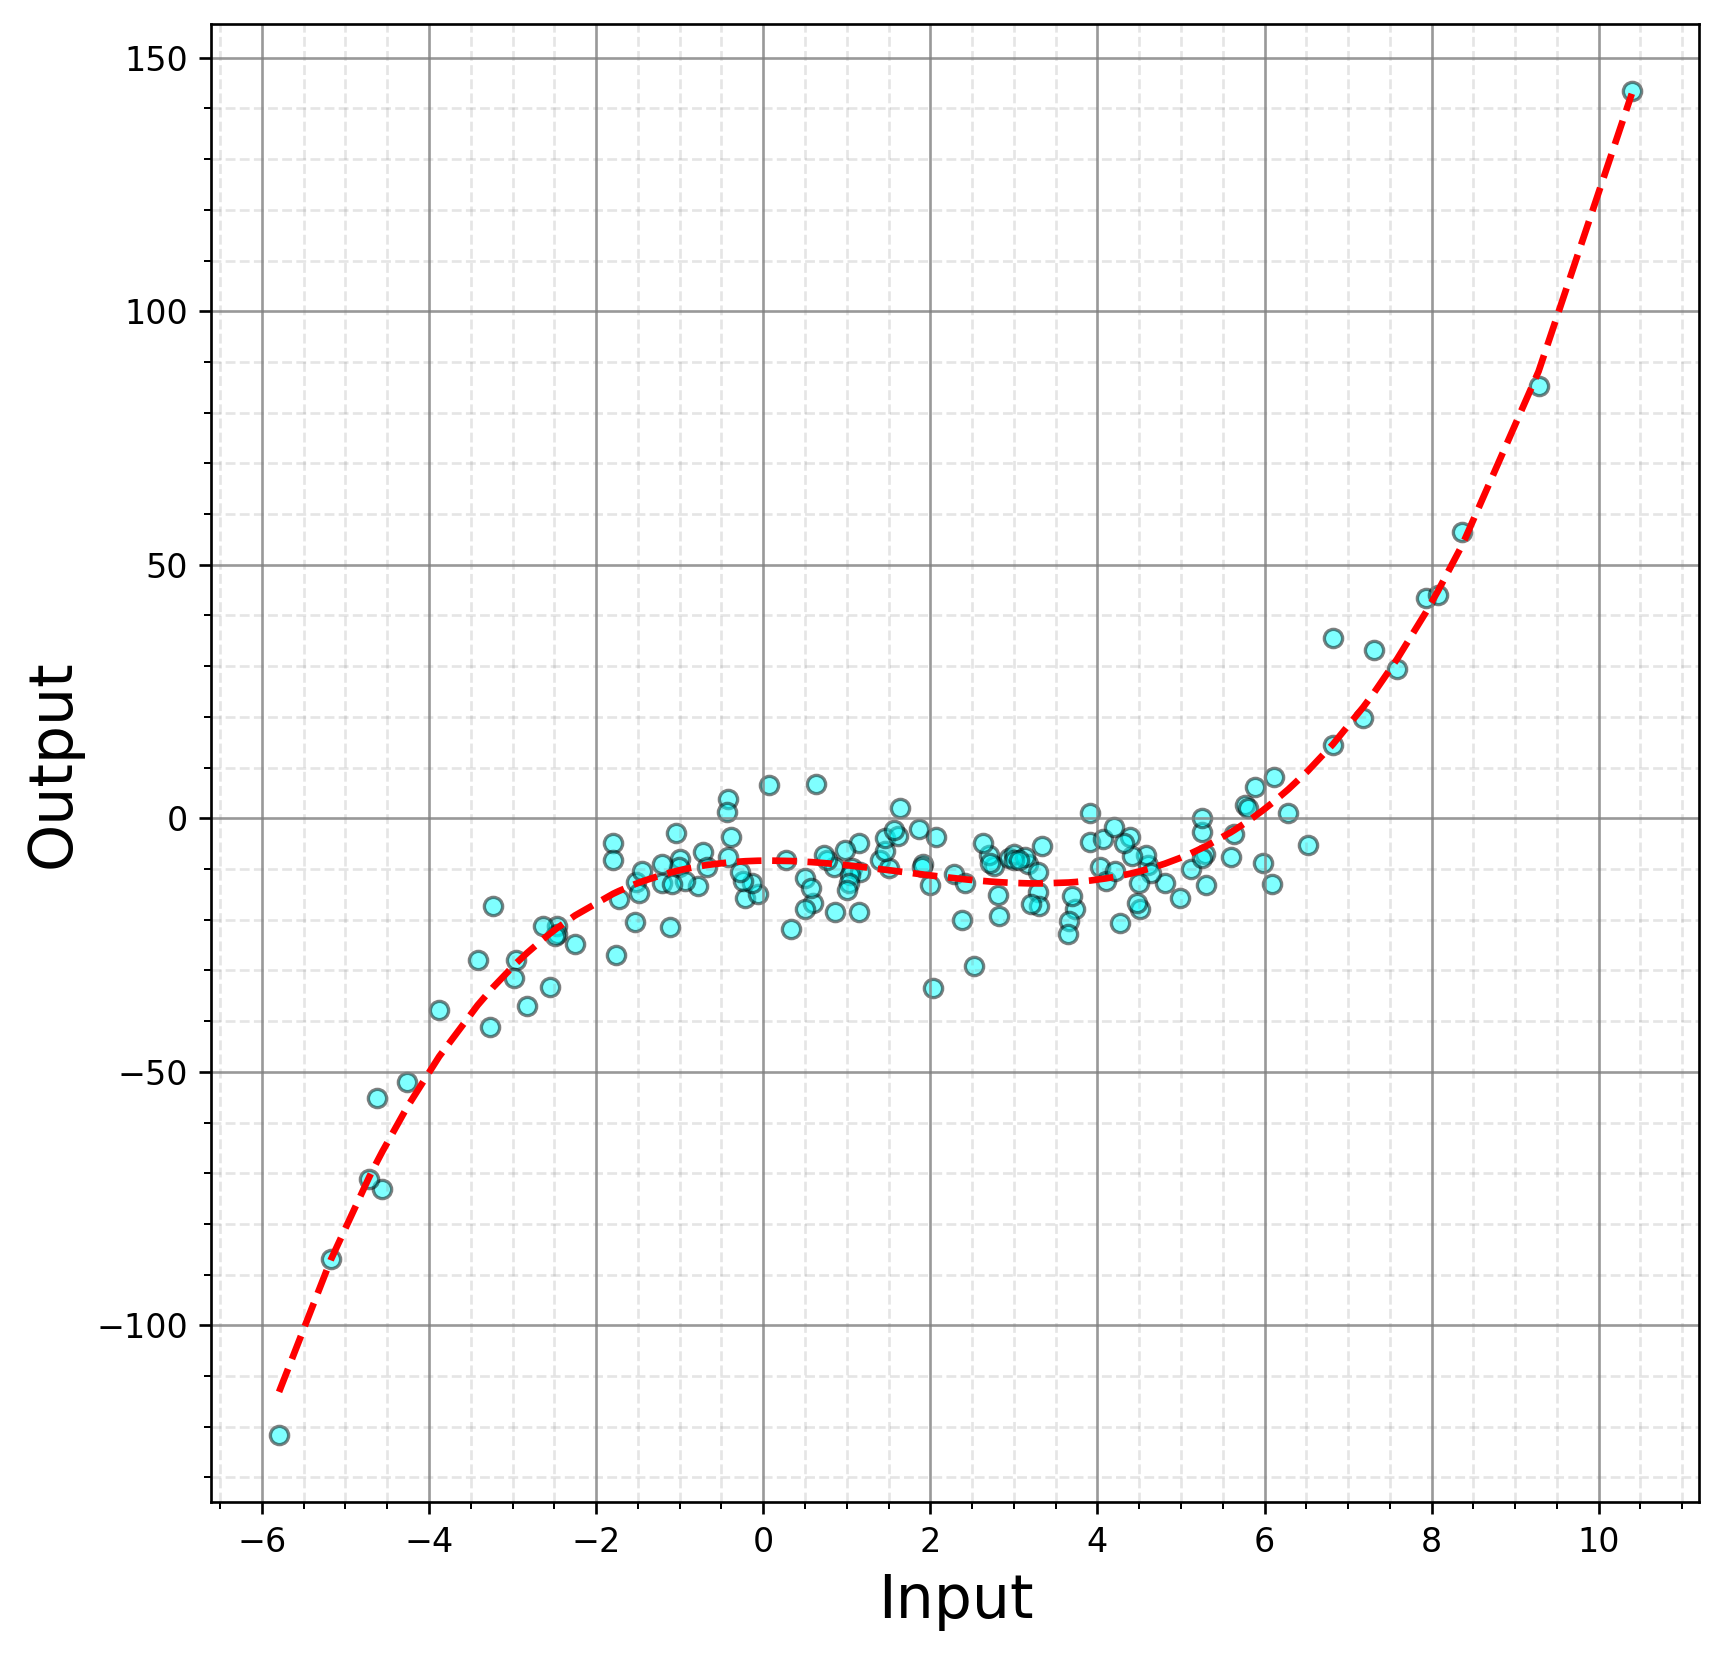

In [21]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6)
ax.scatter(x, y, s=30,ec='k',color='cyan',alpha=0.5)
# sort the values of x before line plot
sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
x_sorted, y_poly_pred_sortedbyx = zip(*sorted_zip)
ax.plot(x_sorted, y_poly_pred_sortedbyx, color='r',linestyle='--',lw=2)
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

In [ ]:
model.score(x_poly,y)

0.907817231070616

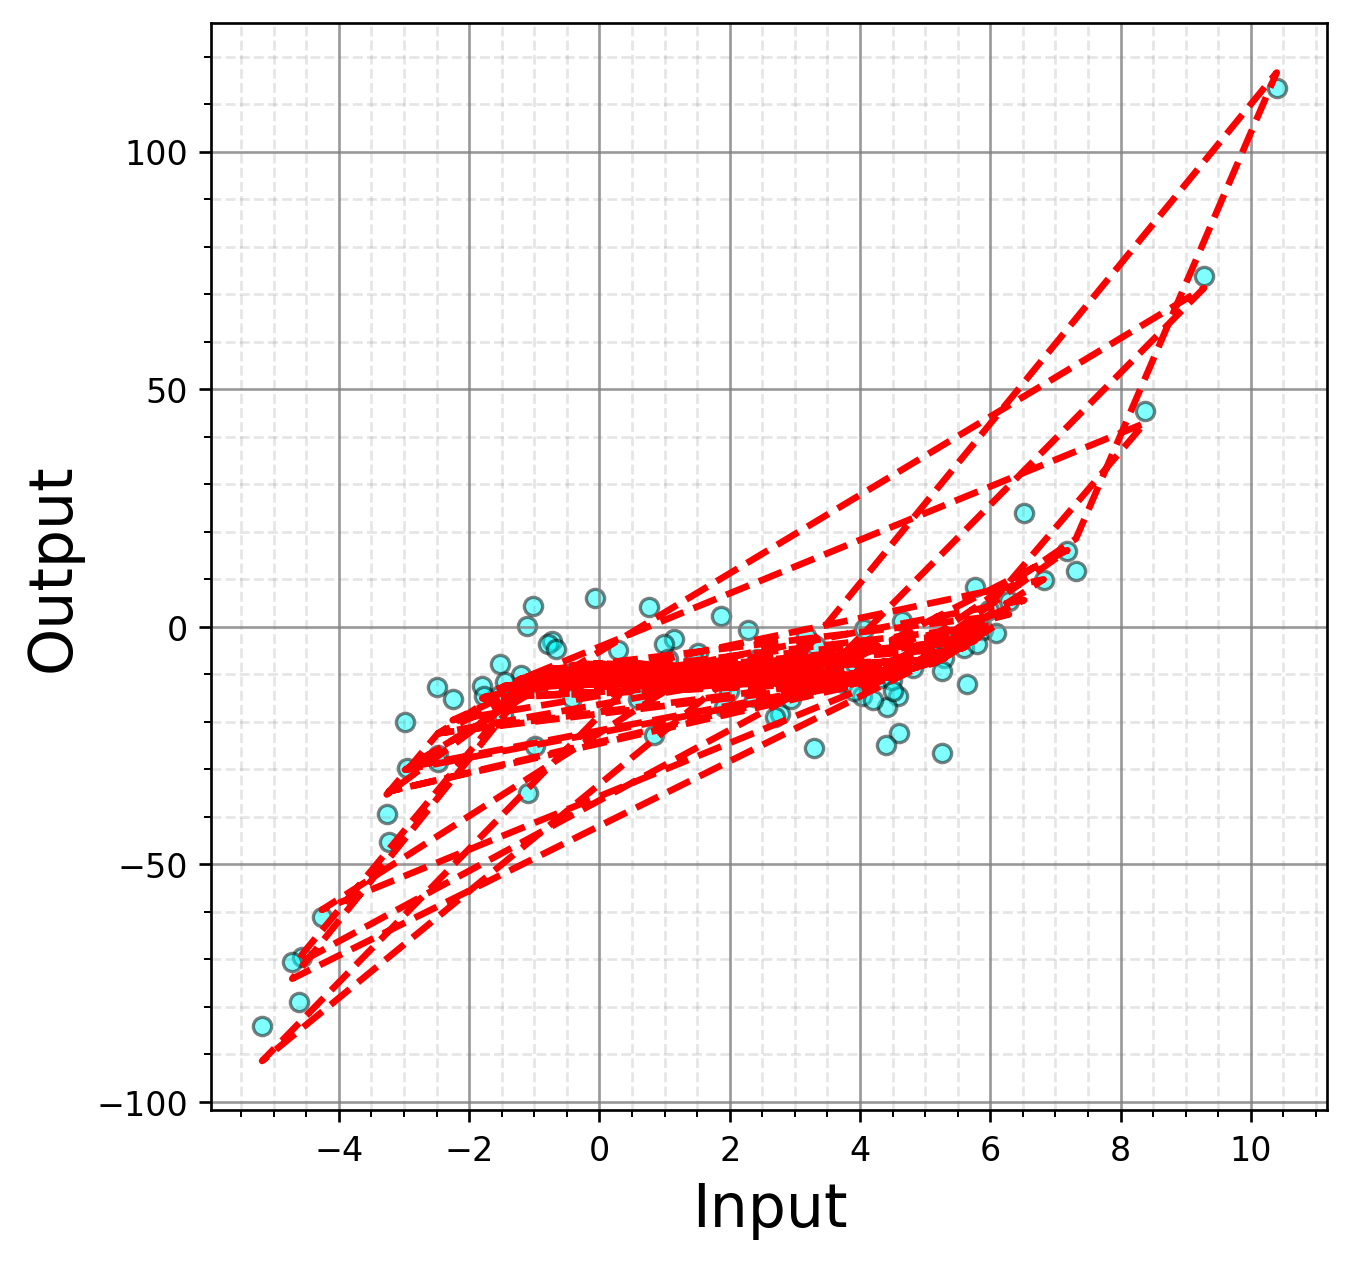

In [ ]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6)
ax.scatter(x, y, s=30,ec='k',color='cyan',alpha=0.5)
# sort the values of x before line plot
#sort_axis = operator.itemgetter(0)
#sorted_zip = sorted(zip(x,y_poly_pred), key=sort_axis)
#x_sorted, y_poly_pred = zip(*sorted_zip)
ax.plot(x, y_poly_pred, color='r',linestyle='--',lw=2)
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(b=True,which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(b=True,which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

##<font color='red'> In general, a nonlinear function is not always a polynomial. Example: a noisy sine wave</font>

In [ ]:
x = np.linspace(0,np.pi,150)
epsilon = np.random.normal(scale=0.2,size=x.shape)
y = np.sin(4*x) + epsilon

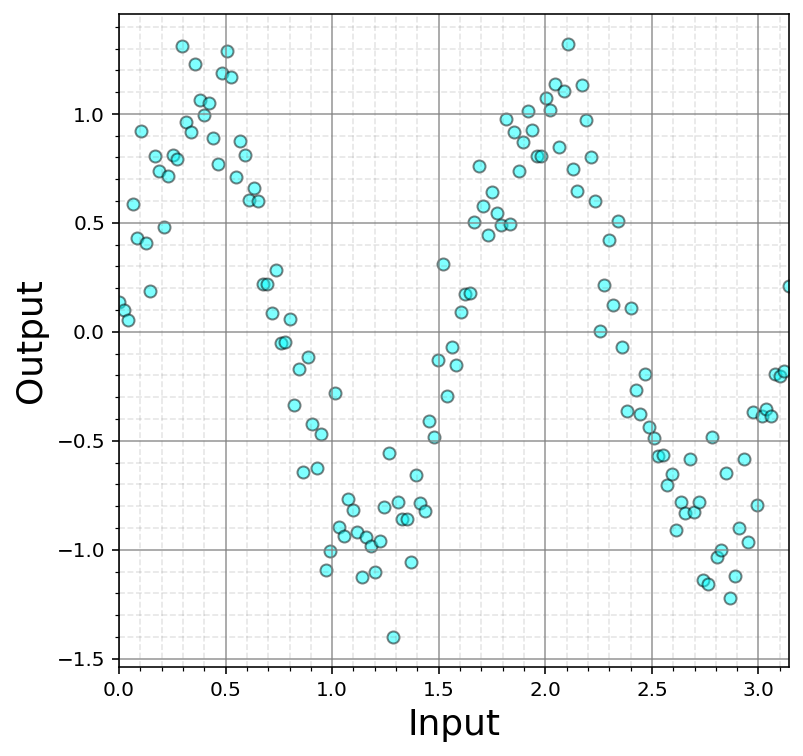

In [ ]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6) # here we setup a desired figure size.
ax.scatter(x,y,ec='k',color='cyan',alpha=0.5) # we generate a scatter plot of x and y
ax.set_xlim([0,np.pi]) # we set the bounds for the horizontal axis
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(b=True,which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(b=True,which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
plt.show()

In class example: fit a polynomial function

In [ ]:
# create polynomial features and "guess" the best degree for this example
poly = PolynomialFeatures(degree=7)
xpoly = poly.fit_transform(x.reshape(-1,1))
model = LinearRegression(fit_intercept=False)
model.fit(xpoly,y)
yhat = model.predict(xpoly)

The R2 coefficient of determination is : 0.924575829262226


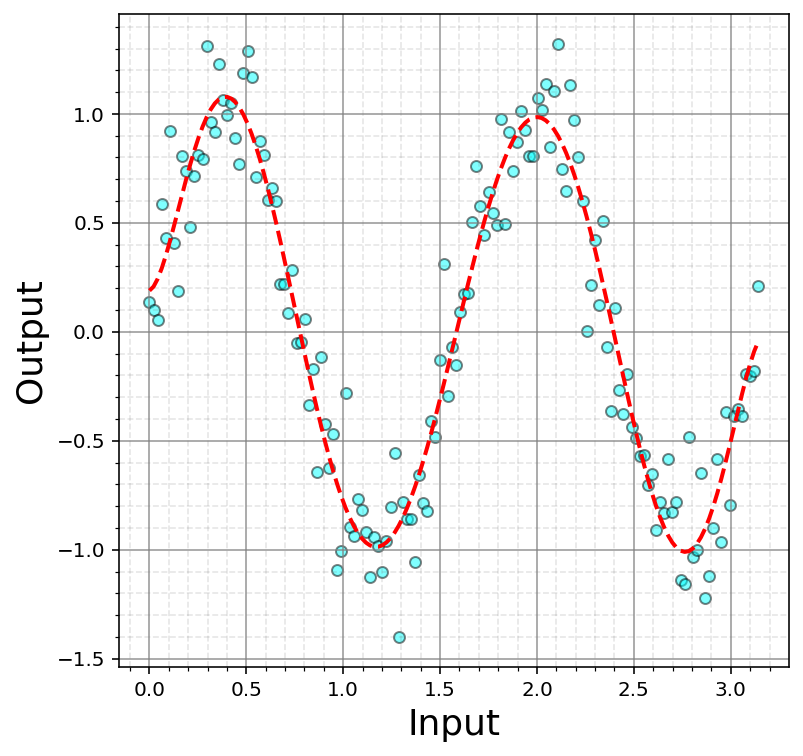

In [ ]:
fig, ax = plt.subplots()
plt.rcParams["figure.figsize"] = (6,6)
ax.scatter(x, y, s=30,ec='k',color='cyan',alpha=0.5)
# sort the values of x before line plot
ax.plot(x, yhat, color='r',linestyle='--',lw=2)
ax.set_xlabel('Input',fontsize=18)
ax.set_ylabel('Output',fontsize=18)
ax.grid(b=True,which='major', color ='grey', linestyle='-', alpha=0.8)
ax.grid(b=True,which='minor', color ='grey', linestyle='--', alpha=0.2)
ax.minorticks_on()
print('The R2 coefficient of determination is : ' +str(model.score(xpoly,y)))
plt.show()

## 2. Polynomial models with two or more variables

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
cars = pd.read_csv('drive/My Drive/Data Sets/cars.csv')

In [ ]:
cars

,MPG,CYL,ENG,WGT
0,18.0,8,307.0,3504
1,15.0,8,350.0,3693
2,18.0,8,318.0,3436
3,16.0,8,304.0,3433
4,17.0,8,302.0,3449
...,...,...,...,...
387,27.0,4,140.0,2790
388,44.0,4,97.0,2130
389,32.0,4,135.0,2295
390,28.0,4,120.0,2625


In [ ]:
X = cars[['ENG','WGT']]

In [ ]:
scale = StandardScaler()
X = pd.DataFrame(data=scale.fit_transform(X), columns=X.columns)

In [ ]:
X

,ENG,WGT
0,1.077290,0.620540
1,1.488732,0.843334
2,1.182542,0.540382
3,1.048584,0.536845
4,1.029447,0.555706
...,...,...
387,-0.520637,-0.221125
388,-0.932079,-0.999134
389,-0.568479,-0.804632
390,-0.712005,-0.415627


In [ ]:
def PolynomialFeatures_labeled(input_df,power):
    '''Basically this is a cover for the sklearn preprocessing function.
    The problem with that function is if you give it a labeled dataframe, it ouputs an unlabeled dataframe with potentially
    a whole bunch of unlabeled columns.
    Inputs:
    input_df = Your labeled pandas dataframe (list of x's not raised to any power)
    power = what order polynomial you want variables up to. (use the same power as you want entered into pp.PolynomialFeatures(power) directly)
    Ouput:
    Output: This function relies on the powers_ matrix which is one of the preprocessing function's outputs to create logical labels and
    outputs a labeled pandas dataframe
    https://gist.github.com/michaelguia/a87d76eb6722a90893f375bff87260f7
    '''
    poly = PolynomialFeatures(power)
    output_nparray = poly.fit_transform(input_df)
    powers_nparray = poly.powers_

    input_feature_names = list(input_df.columns)
    target_feature_names = ["Constant Term"]
    for feature_distillation in powers_nparray[1:]:
        intermediary_label = ""
        final_label = ""
        for i in range(len(input_feature_names)):
            if feature_distillation[i] == 0:
                continue
            else:
                variable = input_feature_names[i]
                power = feature_distillation[i]
                intermediary_label = "%s^%d" % (variable,power)
                if final_label == "":         #If the final label isn't yet specified
                    final_label = intermediary_label
                else:
                    final_label = final_label + " * " + intermediary_label
        target_feature_names.append(final_label)
    output_df = pd.DataFrame(output_nparray, columns = target_feature_names)
    return output_df

In [ ]:
df = PolynomialFeatures_labeled(X,6)

In [ ]:
len(df.columns)

28

### Message: The histogram does not quite look like a normal distribution. We can also consider a Q-Q Plot:

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  """


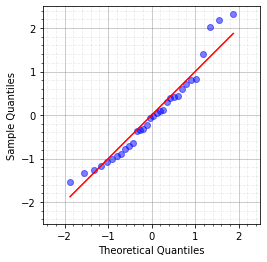

In [ ]:
import statsmodels.api as sm
sm.qqplot(residuals/np.std(residuals), loc = 0, scale = 1, line='s',alpha=0.5)
plt.xlim([-2.5,2.5])
plt.ylim([-2.5,2.5])
plt.axes().set_aspect('equal')
plt.grid(b=True,which='major', color ='grey', linestyle='-', alpha=0.5)
plt.grid(b=True,which='minor', color ='grey', linestyle='--', alpha=0.15)
plt.minorticks_on()
plt.show()

In [ ]:
dist = getattr(stats, 'norm')
params = dist.fit(residuals)

In [ ]:
params

(-8.215650382226158e-15, 2.949162685955028)

In [ ]:
# here we apply the test
stats.kstest(residuals, "norm", params)

KstestResult(statistic=0.08217402470387336, pvalue=0.9821261392158506)

### The conclusion, in our case, is that the normality assumption is not violated.

In [ ]:
# for your convenience, this is the table with the critical values for the
# Kolmogorov-Smirnov test

def ks_critical_value(n_trials, alpha):
    return ksone.ppf(1-alpha/2, n_trials)

trials = range(1, 40)
alphas = [0.1, 0.05, 0.02, 0.01]

# Print table headers
print('{:<6}|{:<6} Level of significance, alpha'.format(' ', ' '))
print('{:<6}|{:>8} {:>8} {:>8} {:>8}'.format(*['Trials'] + alphas))
print('-' * 42)
# Print critical values for each n_trials x alpha combination
for t in trials:
    print('{:6d}|{:>8.5f} {:>8.5f} {:>8.5f} {:>8.5f}'
          .format(*[t] + [ks_critical_value(t, a) for a in alphas]))
    if t % 10 == 0:
        print()

In [ ]:
ks_critical_value(31,0.4)

0.15594527177147208

### A different normality test indicates the same thing

In [ ]:
stats.anderson(residuals,dist='norm')

AndersonResult(statistic=0.46842144463906266, critical_values=array([0.523, 0.596, 0.715, 0.834, 0.992]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]))

In [ ]:
stats.shapiro(residuals)

(0.9450768828392029, 0.10438867658376694)

In [ ]:
#@title
model = sm.OLS(y, x)
results = model.fit()
print(results.summary())

In [ ]:
x = cars.iloc[:,2:8]
x

,cyl,disp,hp,drat,wt,qsec
0,6,160.0,110,3.90,2.620,16.46
1,6,160.0,110,3.90,2.875,17.02
2,4,108.0,93,3.85,2.320,18.61
3,6,258.0,110,3.08,3.215,19.44
4,8,360.0,175,3.15,3.440,17.02
5,6,225.0,105,2.76,3.460,20.22
6,8,360.0,245,3.21,3.570,15.84
7,4,146.7,62,3.69,3.190,20.00
8,4,140.8,95,3.92,3.150,22.90
9,6,167.6,123,3.92,3.440,18.30


In [ ]:
model.fit(x,y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [ ]:
model.score(x,y)

0.8548224115848234

In [ ]:
residuals = y - model.predict(x)

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


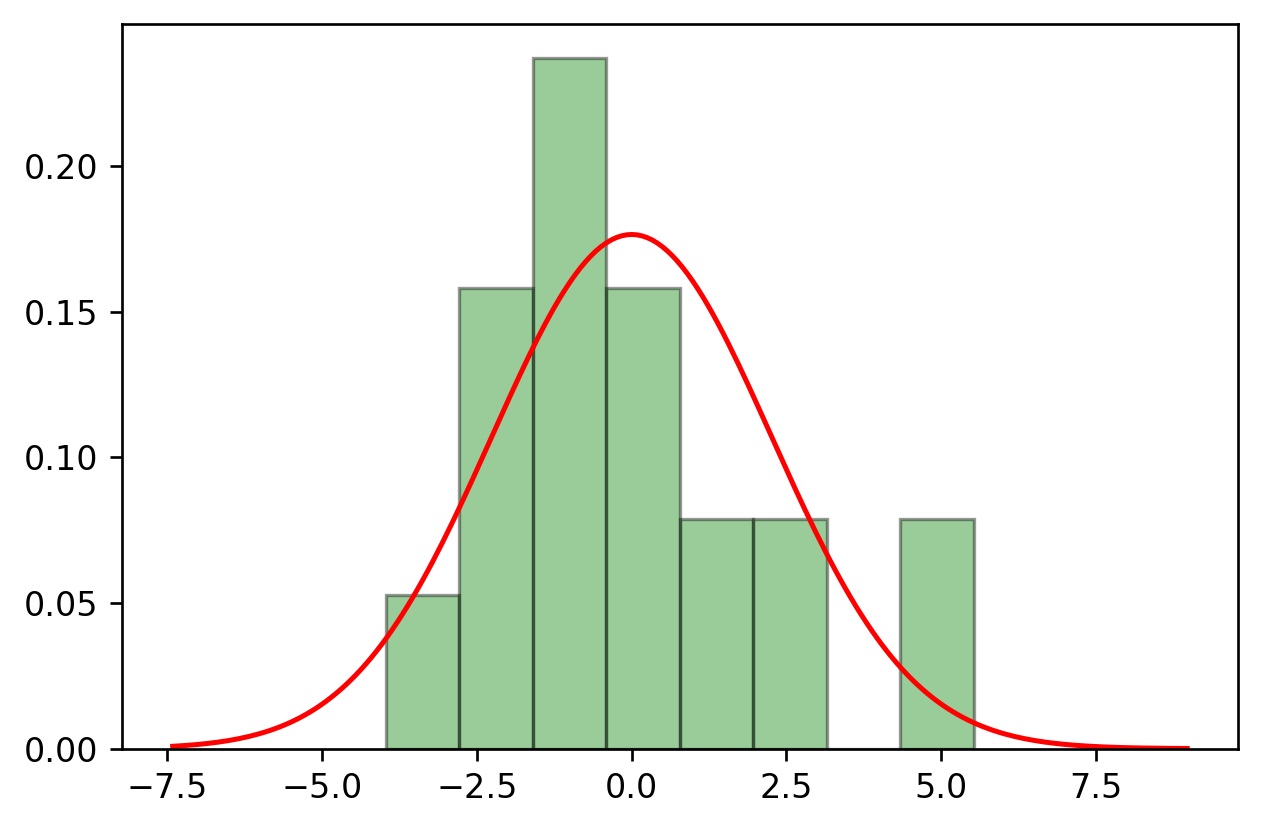

In [ ]:

sns.distplot(residuals,
                  bins=8,
                  kde=False,
                  color='deepskyblue',
                  hist_kws={"color":'green','ec':'black'},
                  fit=stats.norm,
                  fit_kws={"color":'red'})
plt.show()

In [ ]:
dist = getattr(stats, 'norm')
params = dist.fit(residuals)

In [ ]:
# here we apply the Kolmogorov-Smirnov test
stats.kstest(residuals, "norm", params) # the confidence has increased compared to the case of using only one input feature.

KstestResult(statistic=0.15722261669146254, pvalue=0.37091468826166857)